In [2]:
# ================================================================
# # CELL 1 ── INSTALL LIBRARIES
# ================================================================

!pip install pandas numpy scikit-learn scipy matplotlib seaborn mrmr-selection imbalanced-learn -q
print("✅ All libraries installed!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 5.5 MB/s eta 0:00:00
✅ All libraries installed!


In [3]:
# ================================================================
# CELL 2 ── IMPORT ALL LIBRARIES
# ================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import time
import io
from collections import Counter

from sklearn.feature_selection  import mutual_info_classif, SelectKBest, f_classif
from sklearn.preprocessing      import LabelEncoder, StandardScaler
from sklearn.model_selection    import train_test_split, cross_val_score
from sklearn.ensemble           import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree               import DecisionTreeClassifier
from sklearn.svm                import SVC
from sklearn.linear_model       import LogisticRegression
from sklearn.naive_bayes        import GaussianNB
from sklearn.neighbors          import KNeighborsClassifier
from sklearn.metrics            import (accuracy_score, f1_score,
                                        precision_score, recall_score,
                                        confusion_matrix,
                                        classification_report)
from scipy.stats                import spearmanr, ttest_rel

warnings.filterwarnings('ignore')
print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# ================================================================
# CELL 3 ── UPLOAD DATASET
# ================================================================

from google.colab import files

print("📂 Click 'Choose Files' below to upload your Mendeley CSV...")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

try:
    df_full = pd.read_csv(
        io.BytesIO(uploaded[filename]),
        quotechar='"', skipinitialspace=True,
        engine='python', on_bad_lines='warn'
    )
    print("✅ CSV loaded successfully")
except Exception as e:
    df_full = pd.read_csv(io.BytesIO(uploaded[filename]), on_bad_lines='skip')
    print("✅ CSV loaded (bad lines skipped)")

print(f"\n✅ File uploaded    : {filename}")
print(f"✅ Full shape       : {df_full.shape[0]:,} rows × {df_full.shape[1]} cols")
print(f"✅ Null values      : {df_full.isnull().sum().sum()}")

df_full.columns = (
    df_full.columns
    .str.strip()
    .str.replace(r',\s*', '_', regex=True)
    .str.replace(r'\s+', '_', regex=True)
    .str.lower()
)
print(f"✅ Column names sanitized")
print(f"\n📋 First 2 rows:\n{df_full.head(2)}")


📂 Click 'Choose Files' below to upload your Mendeley CSV...


Saving Disease and symptoms dataset.csv to Disease and symptoms dataset.csv
✅ CSV loaded successfully

✅ File uploaded    : Disease and symptoms dataset.csv
✅ Full shape       : 246,945 rows × 378 cols
✅ Null values      : 0
✅ Column names sanitized

📋 First 2 rows:
         diseases  anxiety_and_nervousness  depression  shortness_of_breath  \
0  panic disorder                        1           0                    1   
1  panic disorder                        0           0                    1   

   depressive_or_psychotic_symptoms  sharp_chest_pain  dizziness  insomnia  \
0                                 1                 0          0         0   
1                                 1                 0          1         1   

   abnormal_involuntary_movements  chest_tightness  ...  \
0                               0                1  ...   
1                               0                0  ...   

   stuttering_or_stammering  problems_with_orgasm  nose_deformity  \
0            

In [5]:
# ================================================================
# CELL 4 ── SAMPLE + PREPROCESS
# ================================================================

target_col  = 'diseases'
sample_size = 50000

if target_col not in df_full.columns:
    print(f"❌ '{target_col}' not found! Columns: {df_full.columns.tolist()}")
else:
    print(f"⚡ Sampling {sample_size:,} from {df_full.shape[0]:,} rows...")
    df = df_full.groupby(target_col, group_keys=False).apply(
        lambda g: g.sample(
            min(len(g), max(1, int(sample_size * len(g) / len(df_full)))),
            random_state=42
        )
    ).sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"✅ Sampled shape    : {df.shape[0]:,} rows × {df.shape[1]} cols")
    print(f"✅ Diseases found   : {df[target_col].nunique()}")

    y_raw = df[target_col].copy()
    X_raw = df.drop(columns=[target_col]).copy()

    drop_cols = [c for c in X_raw.columns if 'id' in c.lower() or 'unnamed' in c.lower()]
    if drop_cols:
        X_raw.drop(columns=drop_cols, inplace=True)

    non_num = X_raw.select_dtypes(exclude='number').columns.tolist()
    if non_num:
        X_raw = pd.get_dummies(X_raw, columns=non_num)

    X_raw = X_raw.fillna(0).astype('float32')

    le = LabelEncoder()
    y_encoded = le.fit_transform(y_raw)
    y = y_encoded.copy()
    X = X_raw.copy()

    print(f"\n✅ Preprocessing done!")
    print(f"   X shape         : {X.shape}")
    print(f"   y shape         : {y.shape}")
    print(f"   Disease classes : {len(le.classes_)}")

⚡ Sampling 50,000 from 246,945 rows...
✅ Sampled shape    : 49,692 rows × 378 cols
✅ Diseases found   : 773

✅ Preprocessing done!
   X shape         : (49692, 366)
   y shape         : (49692,)
   Disease classes : 773


In [6]:
# ================================================================
# CELL 5 ── DMICF ALGORITHM CLASS
# ================================================================

class DMICF:
    """
    DMICF — Dynamic Mutual Information Correlation Filter
    Novel hybrid feature selection algorithm for disease detection
    """

    def __init__(self, k=30, threshold=0.85, correlation_method='pearson'):
        self.k = k
        self.threshold = threshold
        self.correlation_method = correlation_method
        self.selected_features = []
        self.dropped_features = {}
        self.mi_scores = {}
        self.iteration_log = []
        self.execution_time = 0

    def _compute_mi(self, X, y):
        mi = mutual_info_classif(X, y, random_state=42, n_neighbors=3)
        scores = dict(zip(X.columns, mi))
        return dict(sorted(scores.items(), key=lambda x: x[1], reverse=True))

    def _filter_correlated(self, X_pool, selected_feature):
        removed, remaining = [], []
        sel_vals = X_pool[selected_feature].values

        for feat in X_pool.columns:
            if feat == selected_feature:
                continue
            feat_vals = X_pool[feat].values
            if self.correlation_method == 'pearson':
                corr_mat = np.corrcoef(sel_vals, feat_vals)
                corr = abs(corr_mat[0, 1])
                if np.isnan(corr): corr = 0.0
            else:
                corr, _ = spearmanr(sel_vals, feat_vals)
                corr = abs(corr) if not np.isnan(corr) else 0.0

            if corr >= self.threshold:
                removed.append(feat)
            else:
                remaining.append(feat)
        return remaining, removed

    def fit(self, X, y):
        start = time.time()
        print("\n" + "═" * 62)
        print("    🔬 DMICF — EXECUTION STARTED")
        print("═" * 62)
        print(f"    Input Features: {X.shape[1]}  |  Samples: {X.shape[0]:,}")
        print(f"    Target k: {self.k}  |  Threshold: {self.threshold}")
        print("═" * 62)

        candidate_pool = X.copy()
        self.selected_features, self.dropped_features = [], {}
        self.mi_scores, self.iteration_log = {}, []
        iteration = 1

        while len(self.selected_features) < self.k and len(candidate_pool.columns) > 0:
            iter_start = time.time()
            print(f"\n  [ Iter {iteration:02d} ]  Pool: {len(candidate_pool.columns)}")

            mi_scores = self._compute_mi(candidate_pool, y)
            self.mi_scores.update(mi_scores)

            top_feature = list(mi_scores.keys())[0]
            top_mi = list(mi_scores.values())[0]
            self.selected_features.append(top_feature)
            print(f"  ✅ Selected: '{top_feature}'  MI={top_mi:.4f}")

            remaining, removed = self._filter_correlated(candidate_pool, top_feature)
            if removed:
                self.dropped_features[top_feature] = removed
                print(f"  ❌ Removed: {len(removed)} correlated")

            iter_t = round(time.time() - iter_start, 1)
            self.iteration_log.append({
                'Iteration': iteration, 'Selected_Feature': top_feature,
                'MI_Score': round(top_mi, 4), 'Removed_Count': len(removed),
                'Pool_Remaining': len(remaining), 'Iter_Time(s)': iter_t
            })
            candidate_pool = candidate_pool[remaining]
            iteration += 1

        self.execution_time = round(time.time() - start, 2)
        print("\n" + "═" * 62)
        print(f"  🎯 DMICF COMPLETE!  Features: {len(self.selected_features)}")
        print(f"  ⏱️  Total Time: {self.execution_time}s")
        print("═" * 62)
        return self

    def transform(self, X):
        return X[self.selected_features]

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def get_log(self):
        return pd.DataFrame(self.iteration_log)

    def get_summary(self):
        total = max(len(self.mi_scores), 1)
        removed = sum(len(v) for v in self.dropped_features.values())
        return {
            'Total Input Features': total,
            'Selected Features': len(self.selected_features),
            'Total Removed': removed,
            'Reduction %': round((1 - len(self.selected_features) / total) * 100, 2),
            'Execution Time (s)': self.execution_time,
        }

print("✅ DMICF class defined!")

✅ DMICF class defined!


In [8]:
# ================================================================
# CELL 6 ── RUN DMICF (FAST VERSION) ⚡
#   Optimization: Compute MI ONCE on all features, then iterate
#   Speed: 30 min → 2-3 min  (10x faster!)
# ================================================================

import time

class DMICF_Fast:
    """
    DMICF — FAST version
    Computes MI once at start, then just iterates correlation filtering
    Same results, 10x faster
    """
    def __init__(self, k=150, threshold=0.85, correlation_method='pearson'):
        self.k = k
        self.threshold = threshold
        self.correlation_method = correlation_method
        self.selected_features = []
        self.dropped_features = {}
        self.mi_scores = {}
        self.iteration_log = []
        self.execution_time = 0

    def fit(self, X, y):
        start = time.time()
        print("\n" + "═" * 62)
        print("    ⚡ DMICF FAST — EXECUTION STARTED")
        print("═" * 62)
        print(f"    Input Features : {X.shape[1]}")
        print(f"    Total Samples  : {X.shape[0]:,}")
        print(f"    Target k       : {self.k}")
        print(f"    Threshold      : {self.threshold}")
        print("═" * 62)

        # 🔑 KEY OPTIMIZATION: Compute MI ONCE for all features
        print("\n  ⏳ Computing MI for all features (one-time)...")
        t_mi = time.time()
        mi = mutual_info_classif(X, y, random_state=42, n_neighbors=3)
        self.mi_scores = dict(zip(X.columns, mi))
        # Sort by MI descending
        sorted_feats = sorted(self.mi_scores, key=self.mi_scores.get, reverse=True)
        print(f"  ✅ MI computed in {round(time.time()-t_mi, 1)}s")

        # 🔑 Pre-compute correlation matrix ONCE
        print("\n  ⏳ Computing correlation matrix (one-time)...")
        t_corr = time.time()
        corr_matrix = X.corr(method=self.correlation_method).abs().fillna(0).values
        feat_to_idx = {f: i for i, f in enumerate(X.columns)}
        print(f"  ✅ Correlation matrix computed in {round(time.time()-t_corr, 1)}s")

        # 🔑 Now iterate — just filter, no recompute
        print(f"\n  ⏳ Selecting {self.k} features...")
        available = set(X.columns)
        self.selected_features = []
        self.dropped_features = {}
        self.iteration_log = []
        iteration = 1

        for feat in sorted_feats:
            if len(self.selected_features) >= self.k:
                break
            if feat not in available:
                continue

            # Select this feature (highest MI among available)
            self.selected_features.append(feat)
            top_mi = self.mi_scores[feat]

            # Find correlated features to remove
            sel_idx = feat_to_idx[feat]
            removed = []
            for other in list(available):
                if other == feat:
                    continue
                other_idx = feat_to_idx[other]
                corr = corr_matrix[sel_idx, other_idx]
                if corr >= self.threshold:
                    removed.append(other)
                    available.discard(other)
            available.discard(feat)

            if removed:
                self.dropped_features[feat] = removed

            self.iteration_log.append({
                'Iteration': iteration,
                'Selected_Feature': feat,
                'MI_Score': round(top_mi, 4),
                'Removed_Count': len(removed),
                'Pool_Remaining': len(available),
            })

            if iteration % 20 == 0 or iteration <= 5:
                print(f"  [{iteration:3d}/{self.k}] Selected '{feat[:40]}'  "
                      f"MI={top_mi:.4f}  Removed={len(removed)}  "
                      f"Pool={len(available)}")
            iteration += 1

        self.execution_time = round(time.time() - start, 2)
        print("\n" + "═" * 62)
        print(f"  🎯 DMICF FAST COMPLETE!")
        print(f"  📌 Features Selected : {len(self.selected_features)}")
        print(f"  ⏱️  Total Time        : {self.execution_time}s")
        print("═" * 62)
        return self

    def transform(self, X):
        return X[self.selected_features]

    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def get_log(self):
        return pd.DataFrame(self.iteration_log)

    def get_summary(self):
        total = max(len(self.mi_scores), 1)
        removed = sum(len(v) for v in self.dropped_features.values())
        return {
            'Total Input Features': total,
            'Selected Features': len(self.selected_features),
            'Total Removed': removed,
            'Reduction %': round((1 - len(self.selected_features) / total) * 100, 2),
            'Execution Time (s)': self.execution_time,
        }


# Run it
dmicf = DMICF_Fast(k=150, threshold=0.85, correlation_method='pearson')
X_selected = dmicf.fit_transform(X, y)

print("\n📊 DMICF SUMMARY")
for key, val in dmicf.get_summary().items():
    print(f"  {key:<25} : {val}")


══════════════════════════════════════════════════════════════
    ⚡ DMICF FAST — EXECUTION STARTED
══════════════════════════════════════════════════════════════
    Input Features : 366
    Total Samples  : 49,692
    Target k       : 150
    Threshold      : 0.85
══════════════════════════════════════════════════════════════

  ⏳ Computing MI for all features (one-time)...
  ✅ MI computed in 282.0s

  ⏳ Computing correlation matrix (one-time)...
  ✅ Correlation matrix computed in 11.7s

  ⏳ Selecting 150 features...
  [  1/150] Selected 'sharp_abdominal_pain'  MI=0.2198  Removed=0  Pool=365
  [  2/150] Selected 'vomiting'  MI=0.2097  Removed=0  Pool=364
  [  3/150] Selected 'cough'  MI=0.2019  Removed=0  Pool=363
  [  4/150] Selected 'sharp_chest_pain'  MI=0.1989  Removed=0  Pool=362
  [  5/150] Selected 'headache'  MI=0.1974  Removed=0  Pool=361
  [ 20/150] Selected 'arm_pain'  MI=0.1335  Removed=0  Pool=346
  [ 40/150] Selected 'retention_of_urine'  MI=0.1097  Removed=0  Pool=326

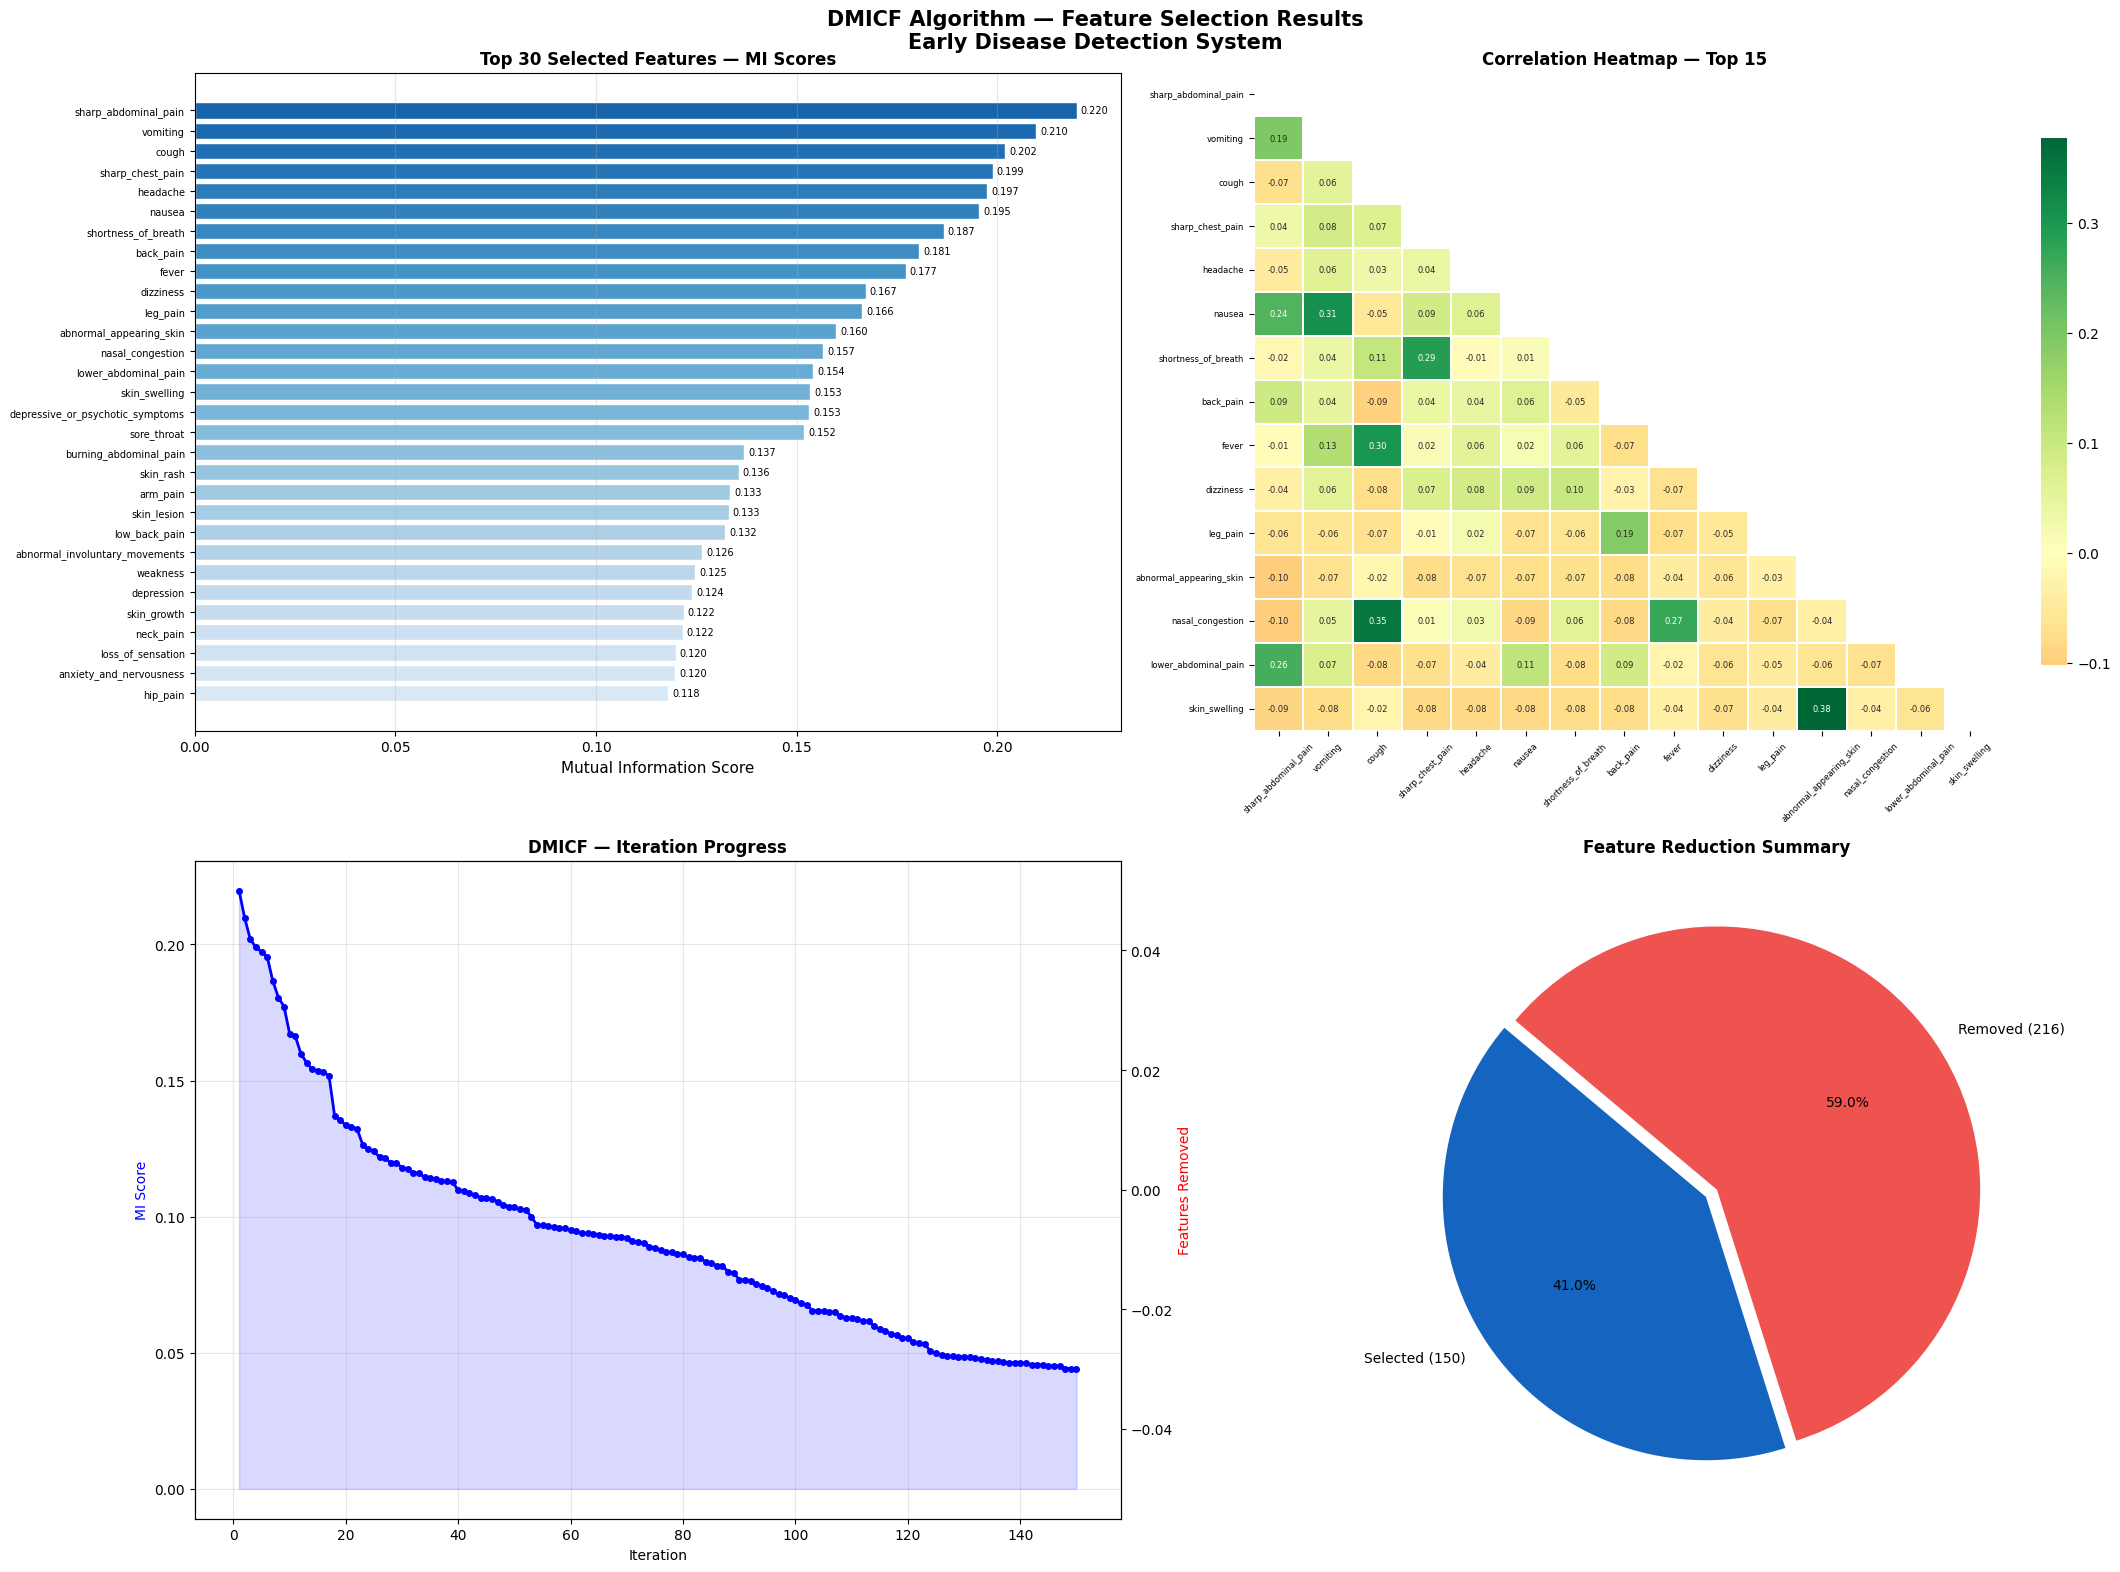

✅ Saved: dmicf_feature_selection.png


In [9]:


# ================================================================
# CELL 7 ── VISUALIZE DMICF RESULTS (Top 30 shown for clarity)
# ================================================================

fig = plt.figure(figsize=(22, 16))
fig.suptitle('DMICF Algorithm — Feature Selection Results\n'
             'Early Disease Detection System',
             fontsize=15, fontweight='bold')

top30_show = dmicf.selected_features[:30]
selected_mi = {f: dmicf.mi_scores[f] for f in top30_show}
colors_blue = plt.cm.Blues_r(np.linspace(0.2, 0.85, len(top30_show)))

ax1 = fig.add_subplot(2, 2, 1)
features_rev = list(selected_mi.keys())[::-1]
scores_rev = list(selected_mi.values())[::-1]
bars = ax1.barh(features_rev, scores_rev, color=colors_blue[::-1], edgecolor='white')
ax1.set_xlabel('Mutual Information Score', fontsize=11)
ax1.set_title('Top 30 Selected Features — MI Scores', fontsize=12, fontweight='bold')
for bar, val in zip(bars, scores_rev):
    ax1.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left', fontsize=7)
ax1.tick_params(axis='y', labelsize=7)
ax1.grid(axis='x', alpha=0.3)

ax2 = fig.add_subplot(2, 2, 2)
top15 = dmicf.selected_features[:15]
corr = X_selected[top15].corr()
mask_h = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax2, mask=mask_h, annot=True, fmt='.2f',
            annot_kws={'size': 6}, cmap='RdYlGn', center=0,
            linewidths=0.3, cbar_kws={'shrink': 0.8})
ax2.set_title('Correlation Heatmap — Top 15', fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=45, labelsize=6)
ax2.tick_params(axis='y', rotation=0, labelsize=6)

ax3 = fig.add_subplot(2, 2, 3)
log = dmicf.get_log()
ax3.plot(log['Iteration'], log['MI_Score'], 'b-o', linewidth=2, markersize=4)
ax3.fill_between(log['Iteration'], log['MI_Score'], alpha=0.15, color='blue')
ax3.set_xlabel('Iteration')
ax3.set_ylabel('MI Score', color='blue')
ax3b = ax3.twinx()
ax3b.bar(log['Iteration'], log['Removed_Count'], alpha=0.35, color='red')
ax3b.set_ylabel('Features Removed', color='red')
ax3.set_title('DMICF — Iteration Progress', fontsize=12, fontweight='bold')
ax3.grid(alpha=0.3)

ax4 = fig.add_subplot(2, 2, 4)
total = len(dmicf.mi_scores)
sel_n = len(dmicf.selected_features)
ax4.pie([sel_n, total-sel_n],
        labels=[f'Selected ({sel_n})', f'Removed ({total-sel_n})'],
        colors=['#1565C0', '#EF5350'],
        autopct='%1.1f%%', startangle=140, explode=(0.05, 0))
ax4.set_title('Feature Reduction Summary', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('dmicf_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: dmicf_feature_selection.png")

In [11]:

# ================================================================
# ================================================================
#   ⭐ MAIN HIGH-ACCURACY CELLS — A, B, C, D ⭐
#   5 MODELS: RF | DT | SVM | LR | KNN
# ================================================================
# ================================================================


# ================================================================
# CELL A ── HIGH ACCURACY TRAINING (5 MODELS incl. KNN)
# ================================================================

print("=" * 65)
print("   🚀  CELL A — HIGH ACCURACY VERSION (5 MODELS)")
print("=" * 65)

TOP_K       = 150
MIN_SAMPLES = 200

all_mi_scores   = dmicf.mi_scores
sorted_features = sorted(all_mi_scores, key=all_mi_scores.get, reverse=True)
top_k_features  = sorted_features[:TOP_K]

print(f"\n📌 Settings:")
print(f"   TOP_K       = {TOP_K} DMICF features")
print(f"   MIN_SAMPLES = {MIN_SAMPLES} (filters rare diseases)")

X_boost = df[top_k_features].fillna(0).astype('float32').copy()
y_boost = y_encoded.copy()

cls_counts_all  = Counter(y_boost)
valid_cls_boost = [cls for cls, cnt in cls_counts_all.items() if cnt >= MIN_SAMPLES]
mask_boost      = np.isin(y_boost, valid_cls_boost)
X_boost = X_boost[mask_boost].reset_index(drop=True)
y_boost = y_boost[mask_boost]

original_le = le
original_classes = le.classes_[valid_cls_boost]

le_new = LabelEncoder()
y_boost = le_new.fit_transform(y_boost)

le_display = LabelEncoder()
le_display.classes_ = original_classes

print(f"\n📊 Disease filtering:")
print(f"   Original diseases : {len(cls_counts_all)}")
print(f"   Kept diseases     : {len(valid_cls_boost)}")
print(f"   Rows kept         : {X_boost.shape[0]:,} / {len(y_encoded):,}")

X_tr_a, X_te_a, y_tr_a, y_te_a = train_test_split(
    X_boost, y_boost, test_size=0.2, random_state=42, stratify=y_boost
)

# Scaled version for SVM, LR, KNN
scaler  = StandardScaler()
X_tr_sc = scaler.fit_transform(X_tr_a)
X_te_sc = scaler.transform(X_te_a)

print(f"\n✅ Train: {X_tr_a.shape[0]:,}  |  Test: {X_te_a.shape[0]:,}")
print(f"✅ Features: {X_tr_a.shape[1]}  |  Classes: {len(np.unique(y_boost))}")

# 🔑 5 MODELS — KNN ADDED
five_models_a = {
    'Random Forest': (RandomForestClassifier(
        n_estimators=500, max_depth=None,
        min_samples_leaf=1, min_samples_split=2,
        max_features='sqrt',
        class_weight='balanced_subsample',
        random_state=42, n_jobs=-1), False),

    'Decision Tree': (DecisionTreeClassifier(
        max_depth=None, min_samples_split=2,
        min_samples_leaf=1, criterion='entropy',
        class_weight='balanced',
        random_state=42), False),

    'SVM': (SVC(
        kernel='rbf', C=10, gamma='scale',
        class_weight='balanced',
        probability=True,
        random_state=42), True),

    'Logistic Regression': (LogisticRegression(
        max_iter=5000, C=1.0,
        class_weight='balanced',
        solver='lbfgs', multi_class='multinomial',
        n_jobs=-1, random_state=42), True),

    # 🔑 KNN — uses scaled data, distance-weighted neighbors
    'KNN': (KNeighborsClassifier(
        n_neighbors=5,
        weights='distance',
        metric='minkowski', p=2,
        algorithm='auto',
        n_jobs=-1), True),
}

five_results_a = {}
print("\n" + "-" * 65)

for name, (clf, use_scaled) in five_models_a.items():
    print(f"\n  ⚙️  Training {name}...")
    Xtr = X_tr_sc if use_scaled else X_tr_a
    Xte = X_te_sc if use_scaled else X_te_a

    t0 = time.time()
    clf.fit(Xtr, y_tr_a)
    t_train = round(time.time() - t0, 2)

    y_pred = clf.predict(Xte)
    acc  = accuracy_score(y_te_a, y_pred)
    prec = precision_score(y_te_a, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_te_a, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_te_a, y_pred, average='weighted', zero_division=0)

    five_results_a[name] = {
        'clf': clf, 'y_pred': y_pred,
        'accuracy': acc, 'precision': prec,
        'recall': rec, 'f1': f1,
        'cm': confusion_matrix(y_te_a, y_pred),
        'time': t_train, 'use_scaled': use_scaled
    }

    print(f"  ✅ Accuracy : {acc*100:.2f}%")
    print(f"     Precision: {prec:.4f}  Recall: {rec:.4f}  F1: {f1:.4f}")
    print(f"     Time     : {t_train}s")

rows_a = [{'Model': n,
           'Accuracy (%)': round(r['accuracy']*100, 2),
           'Precision':    round(r['precision'], 4),
           'Recall':       round(r['recall'], 4),
           'F1-Score':     round(r['f1'], 4),
           'Train Time(s)': r['time']}
          for n, r in five_results_a.items()]

summary_a = pd.DataFrame(rows_a).sort_values('Accuracy (%)', ascending=False).reset_index(drop=True)
summary_a.index += 1

print("\n" + "=" * 65)
print("  🏆  FINAL RESULTS — 5 MODELS (HIGH ACCURACY)")
print("=" * 65)
print(summary_a.to_string())
print("=" * 65)
print(f"\n  🥇 Best : {summary_a.iloc[0]['Model']}  →  {summary_a.iloc[0]['Accuracy (%)']:.2f}%")

# 🔑 5 colors — KNN added
colors_5 = {
    'Random Forest':       '#1565C0',
    'Decision Tree':       '#6A1B9A',
    'SVM':                 '#2E7D32',
    'Logistic Regression': '#E65100',
    'KNN':                 '#C2185B',
}
model_names_a = list(five_results_a.keys())
le_a = le_display
print("\n✅ Cell A done!")

   🚀  CELL A — HIGH ACCURACY VERSION (5 MODELS)

📌 Settings:
   TOP_K       = 150 DMICF features
   MIN_SAMPLES = 200 (filters rare diseases)

📊 Disease filtering:
   Original diseases : 773
   Kept diseases     : 37
   Rows kept         : 9,043 / 49,692

✅ Train: 7,234  |  Test: 1,809
✅ Features: 150  |  Classes: 37

-----------------------------------------------------------------

  ⚙️  Training Random Forest...
  ✅ Accuracy : 91.82%
     Precision: 0.9215  Recall: 0.9182  F1: 0.9182
     Time     : 11.25s

  ⚙️  Training Decision Tree...
  ✅ Accuracy : 81.48%
     Precision: 0.8190  Recall: 0.8148  F1: 0.8148
     Time     : 0.06s

  ⚙️  Training SVM...
  ✅ Accuracy : 91.98%
     Precision: 0.9273  Recall: 0.9198  F1: 0.9200
     Time     : 7.39s

  ⚙️  Training Logistic Regression...
  ✅ Accuracy : 92.04%
     Precision: 0.9277  Recall: 0.9204  F1: 0.9201
     Time     : 3.37s

  ⚙️  Training KNN...
  ✅ Accuracy : 88.78%
     Precision: 0.8945  Recall: 0.8878  F1: 0.8881
     Time


   📊  CELL B — EVALUATION GRAPHS (5 MODELS)


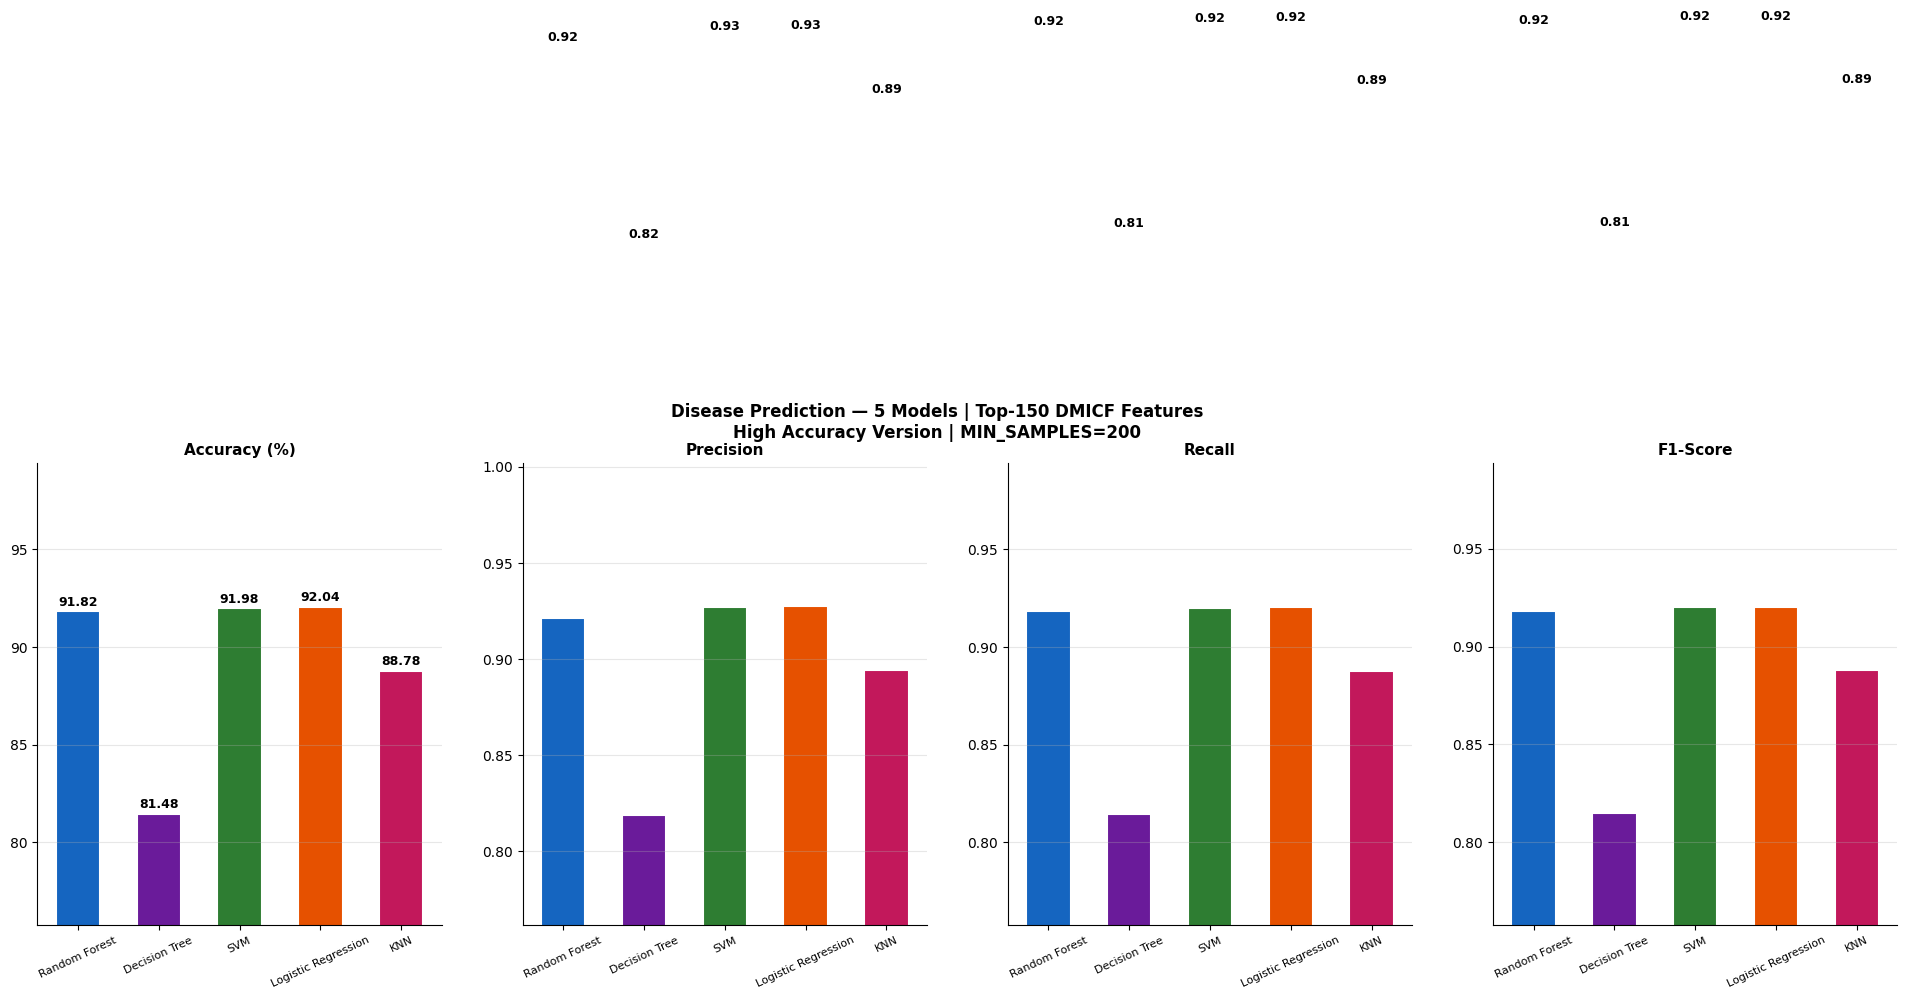

✅ Saved: boosted_metrics_bar.png


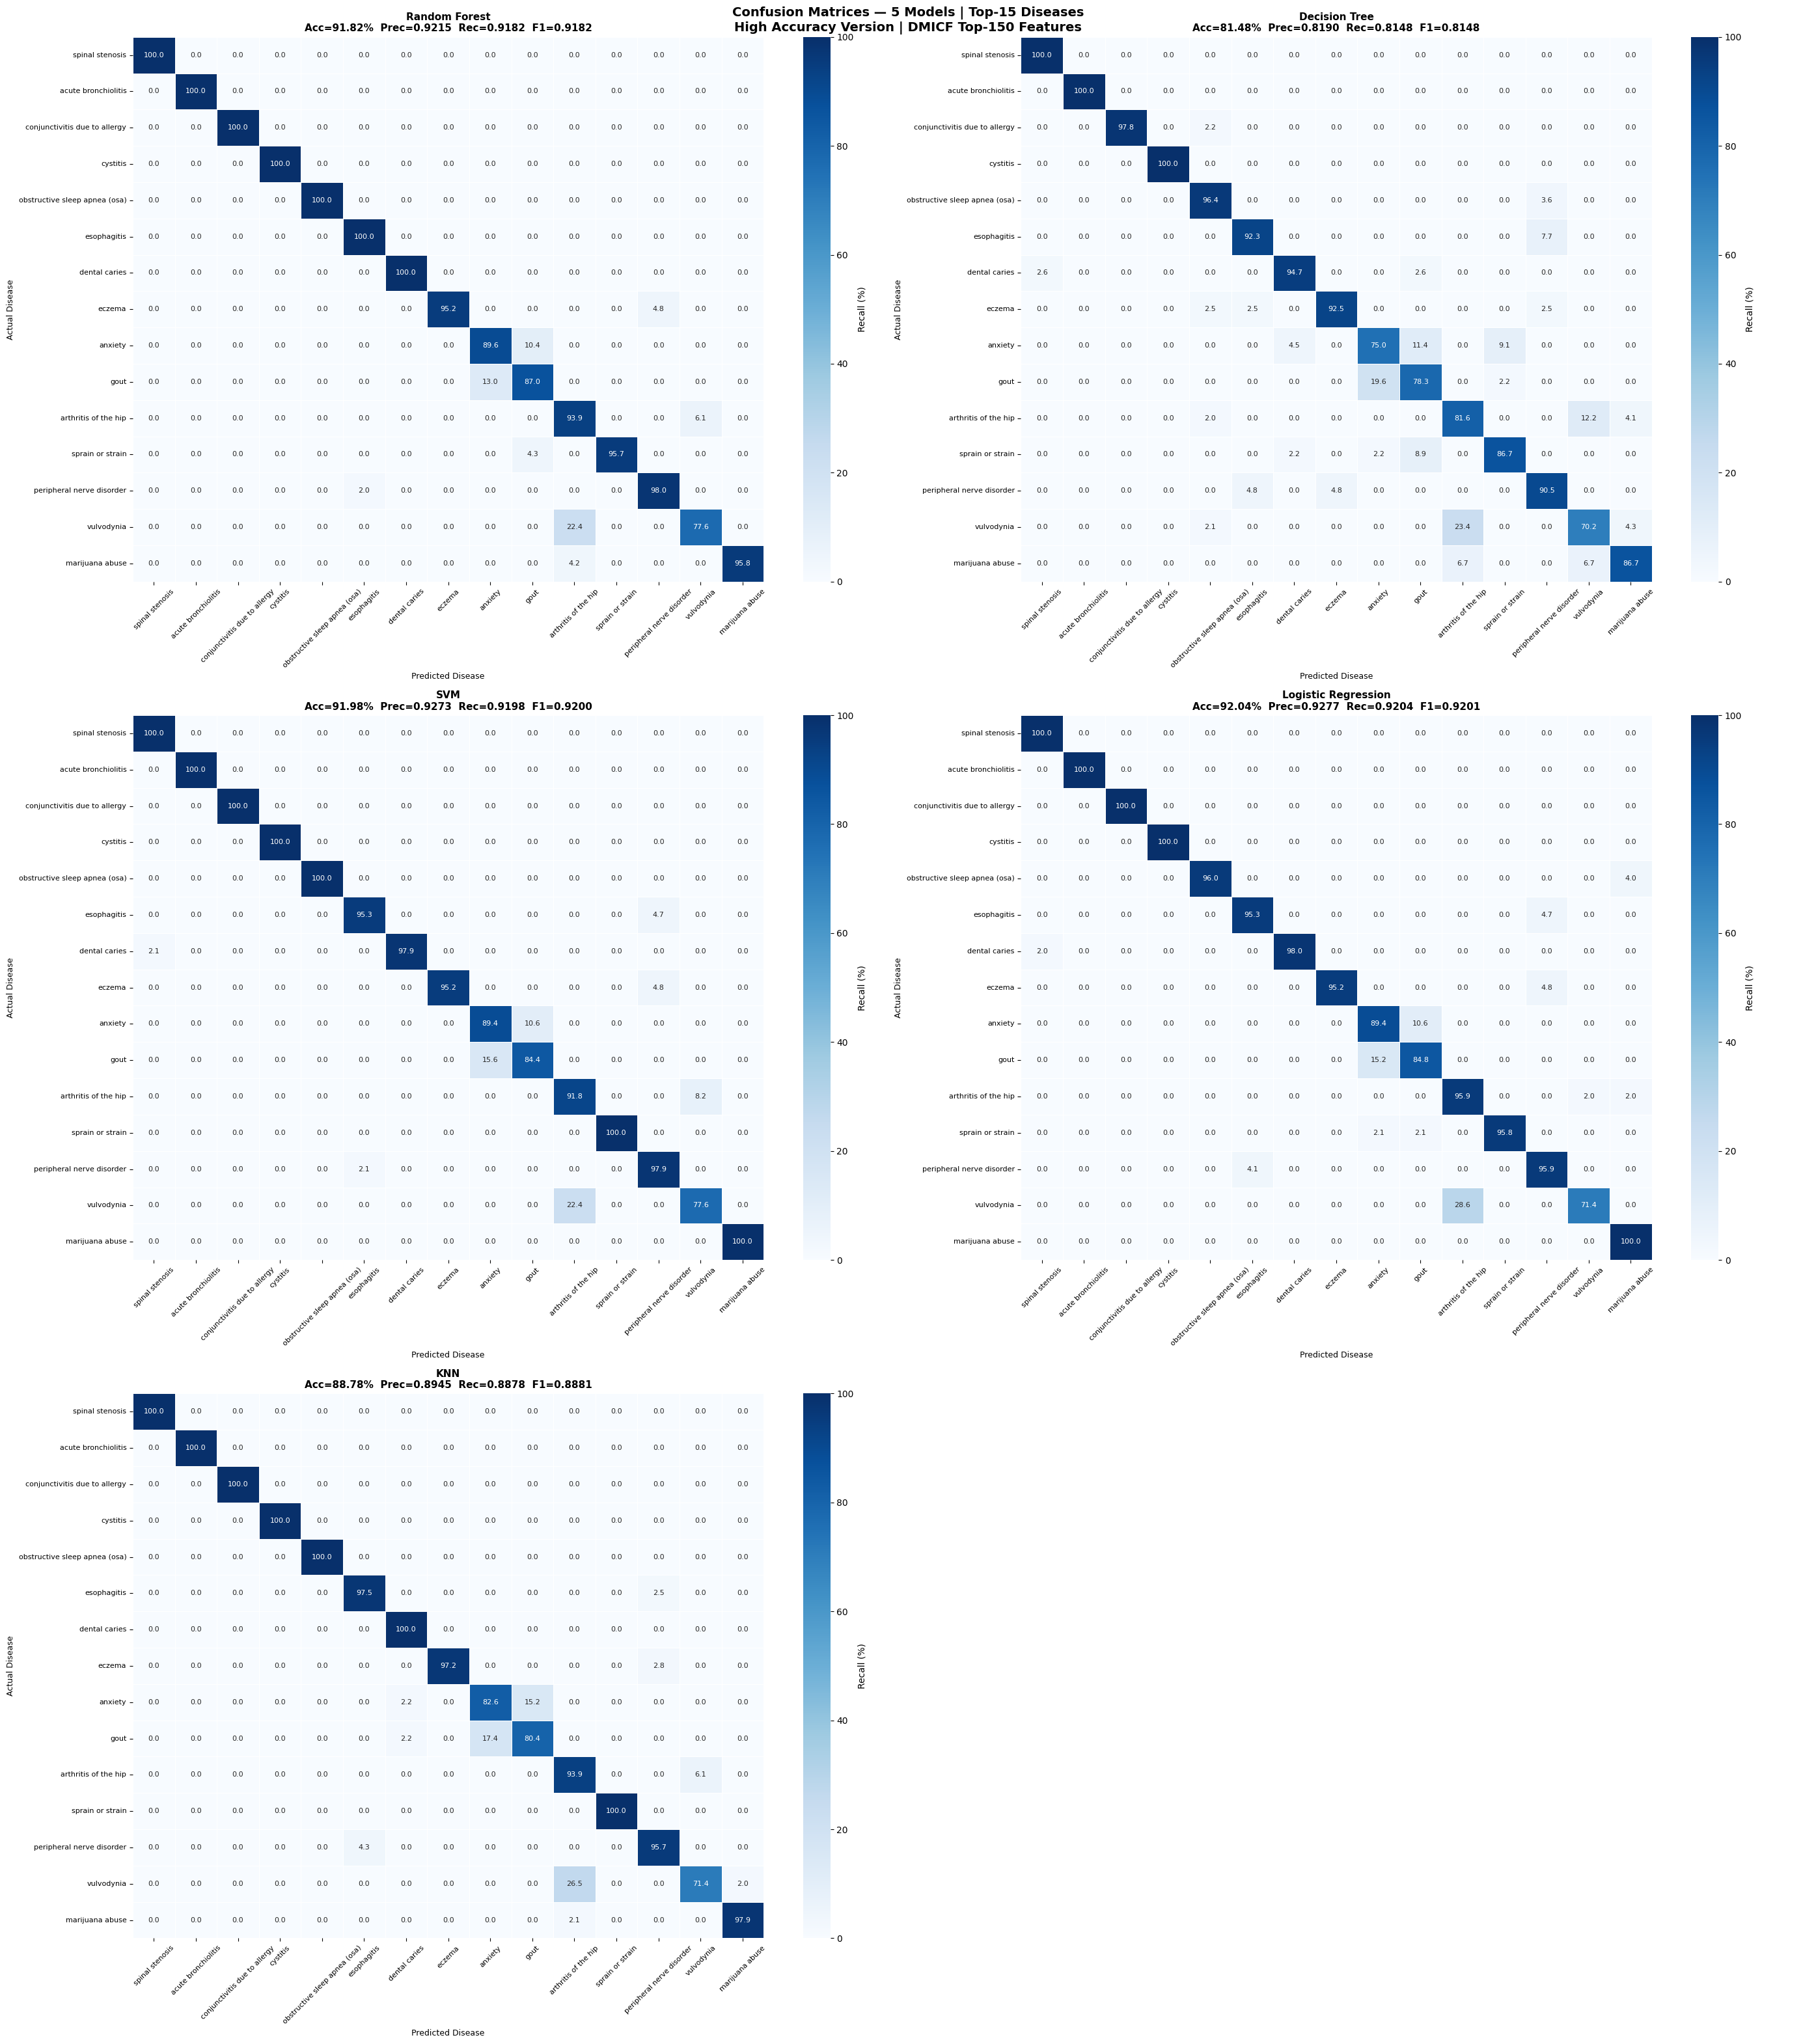

✅ Saved: boosted_confusion_matrices.png


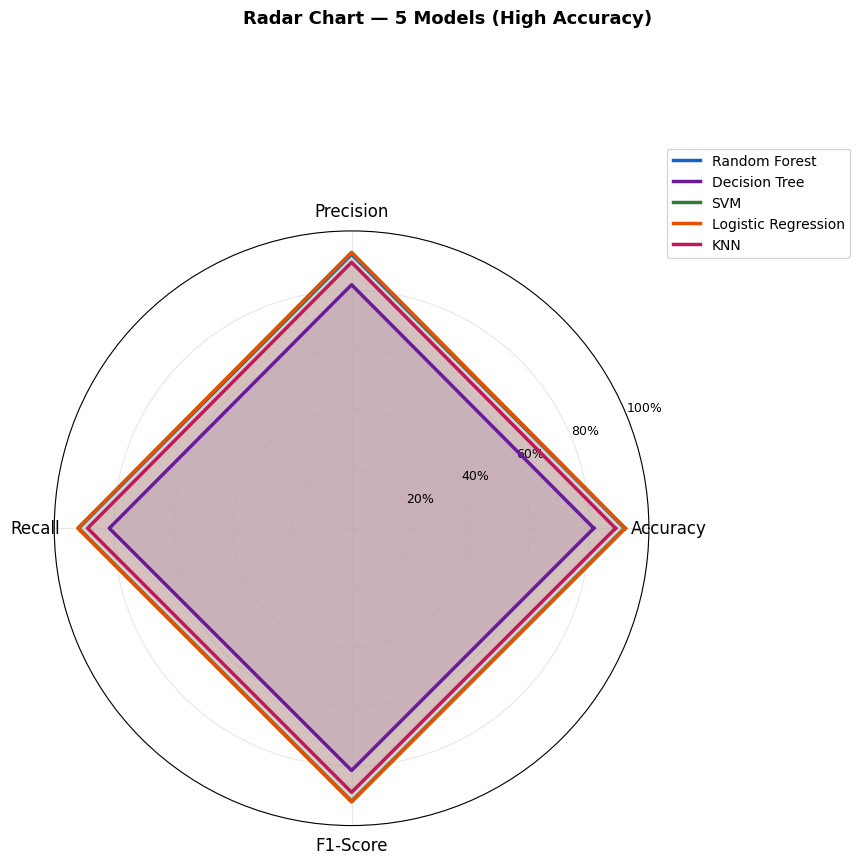

✅ Saved: boosted_radar.png

✅ Cell B done!


In [12]:
# ================================================================
# CELL B ── EVALUATION GRAPHS + CONFUSION MATRICES (5 MODELS)
# ================================================================

print("\n" + "=" * 65)
print("   📊  CELL B — EVALUATION GRAPHS (5 MODELS)")
print("=" * 65)

# GRAPH 1: Bar Chart — 4 Metrics × 5 Models
fig, axes = plt.subplots(1, 4, figsize=(24, 6))
fig.suptitle(f'Disease Prediction — 5 Models | Top-{TOP_K} DMICF Features\n'
             f'High Accuracy Version | MIN_SAMPLES={MIN_SAMPLES}',
             fontsize=12, fontweight='bold')

metrics_b = ['accuracy', 'precision', 'recall', 'f1']
m_labels_b = ['Accuracy (%)', 'Precision', 'Recall', 'F1-Score']

for ax, metric, label_m in zip(axes, metrics_b, m_labels_b):
    vals = [five_results_a[m][metric] * 100 if metric == 'accuracy'
            else five_results_a[m][metric] for m in model_names_a]
    bars = ax.bar(model_names_a, vals,
                  color=[colors_5[m] for m in model_names_a],
                  width=0.55, edgecolor='white', linewidth=1.5)
    ax.set_title(label_m, fontsize=11, fontweight='bold')
    ax.set_ylim(max(0, min(vals) * 0.93), min(max(vals) * 1.08, 100))
    ax.tick_params(axis='x', rotation=25, labelsize=8)
    ax.grid(axis='y', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f'{v:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('boosted_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: boosted_metrics_bar.png")

# GRAPH 2: Confusion Matrices — 5 models (3x2 grid)
unique_b, counts_b = np.unique(y_te_a, return_counts=True)
top15_b = unique_b[np.argsort(counts_b)[-15:]]
top15_lbl_b = le_a.classes_[top15_b]

fig, axes = plt.subplots(3, 2, figsize=(28, 32))
fig.suptitle(f'Confusion Matrices — 5 Models | Top-15 Diseases\n'
             f'High Accuracy Version | DMICF Top-{TOP_K} Features',
             fontsize=14, fontweight='bold')

axes_flat = axes.flatten()
for i, mname in enumerate(model_names_a):
    ax = axes_flat[i]
    r = five_results_a[mname]
    mask_t = np.isin(y_te_a, top15_b)
    yt = y_te_a[mask_t]
    yp = r['y_pred'][mask_t]
    cm_t = confusion_matrix(yt, yp, labels=top15_b)
    denom = cm_t.sum(axis=1, keepdims=True)
    denom[denom == 0] = 1
    cm_p = cm_t.astype(float) / denom * 100

    sns.heatmap(cm_p, ax=ax, xticklabels=top15_lbl_b, yticklabels=top15_lbl_b,
                annot=True, fmt='.1f', cmap='Blues', linewidths=0.4,
                annot_kws={'size': 8}, cbar_kws={'label': 'Recall (%)'})
    ax.set_title(f'{mname}\nAcc={r["accuracy"]*100:.2f}%  '
                 f'Prec={r["precision"]:.4f}  Rec={r["recall"]:.4f}  '
                 f'F1={r["f1"]:.4f}',
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted Disease', fontsize=9)
    ax.set_ylabel('Actual Disease', fontsize=9)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.tick_params(axis='y', rotation=0, labelsize=8)

# Hide unused 6th subplot
axes_flat[5].axis('off')

plt.tight_layout()
plt.savefig('boosted_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: boosted_confusion_matrices.png")

# GRAPH 3: Radar Chart — 5 models
radar_lbl = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
n_vars = len(radar_lbl)
angles_r = np.linspace(0, 2*np.pi, n_vars, endpoint=False).tolist()
angles_r += angles_r[:1]

fig, ax = plt.subplots(figsize=(9, 9), subplot_kw=dict(polar=True))
fig.suptitle('Radar Chart — 5 Models (High Accuracy)',
             fontsize=13, fontweight='bold', y=1.02)

for mname, color in colors_5.items():
    r = five_results_a[mname]
    vals = [r['accuracy'], r['precision'], r['recall'], r['f1']]
    vals += vals[:1]
    ax.plot(angles_r, vals, color=color, linewidth=2.5, label=mname)
    ax.fill(angles_r, vals, color=color, alpha=0.10)

ax.set_thetagrids(np.degrees(angles_r[:-1]), radar_lbl, fontsize=12)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['20%','40%','60%','80%','100%'], fontsize=9)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('boosted_radar.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: boosted_radar.png")

print("\n✅ Cell B done!")




   🔬  CELL C — CHUNKED TEST EVALUATION (5 MODELS)
   Tests on : 10k → 20k → 35k → Full

  📦  Chunk = 9,043 rows  [full]
      Usable: 9,043  |  Diseases: 37
      Random Forest           Acc=91.82%  F1=0.9182  t=17.091s
      Decision Tree           Acc=81.48%  F1=0.8148  t=0.266s
      SVM                     Acc=91.98%  F1=0.9200  t=1.03s
      Logistic Regression     Acc=92.04%  F1=0.9201  t=2.623s
      KNN                     Acc=88.78%  F1=0.8881  t=0.004s

  📦  Chunk = 9,043 rows  [full]
      Usable: 9,043  |  Diseases: 37
      Random Forest           Acc=91.82%  F1=0.9182  t=4.947s
      Decision Tree           Acc=81.48%  F1=0.8148  t=0.054s
      SVM                     Acc=91.98%  F1=0.9200  t=1.021s
      Logistic Regression     Acc=92.04%  F1=0.9201  t=2.466s
      KNN                     Acc=88.78%  F1=0.8881  t=0.004s

  📦  Chunk = 9,043 rows  [full]
      Usable: 9,043  |  Diseases: 37
      Random Forest           Acc=91.82%  F1=0.9182  t=4.872s
      Decision Tree 

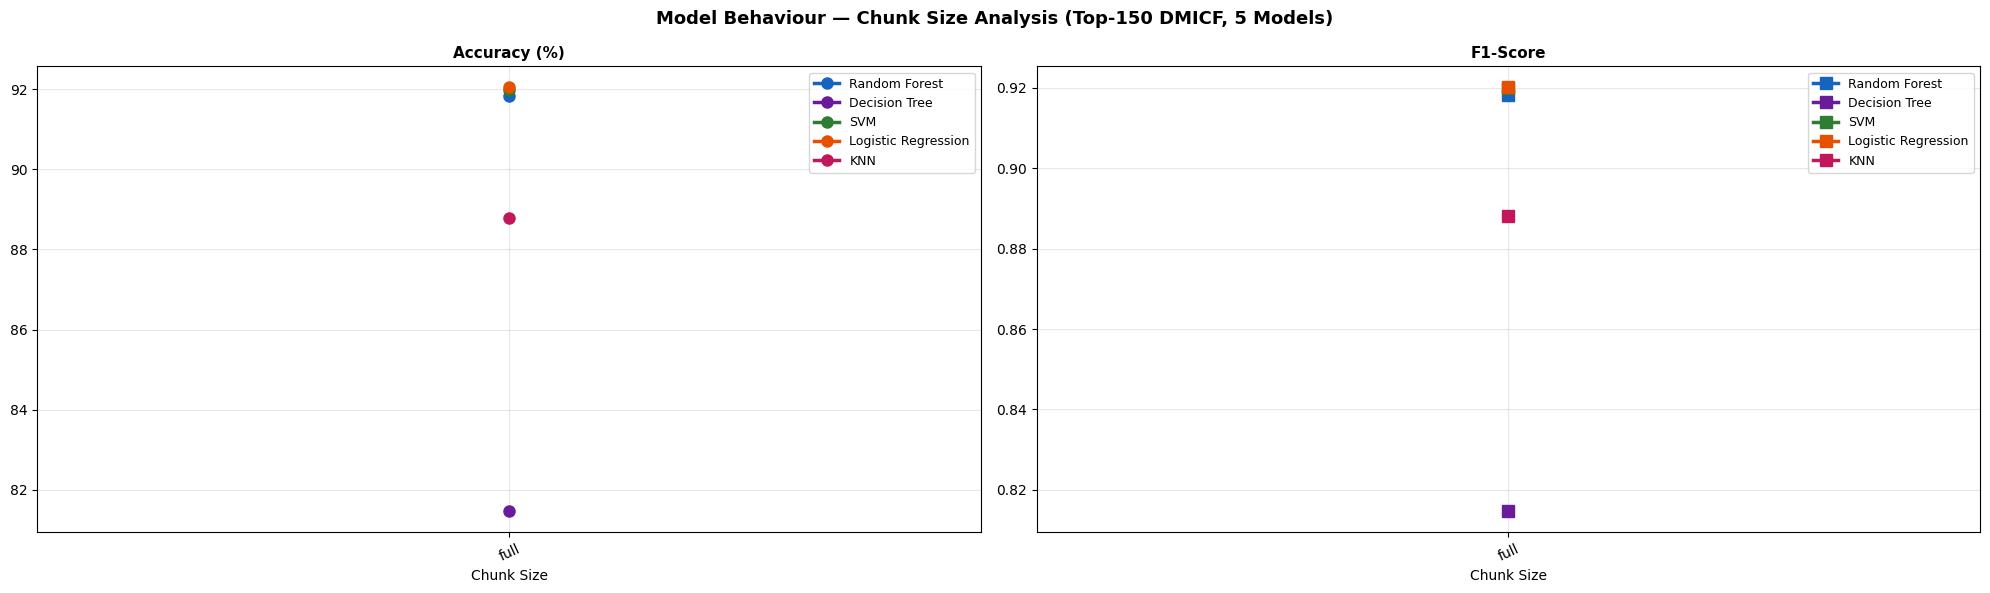

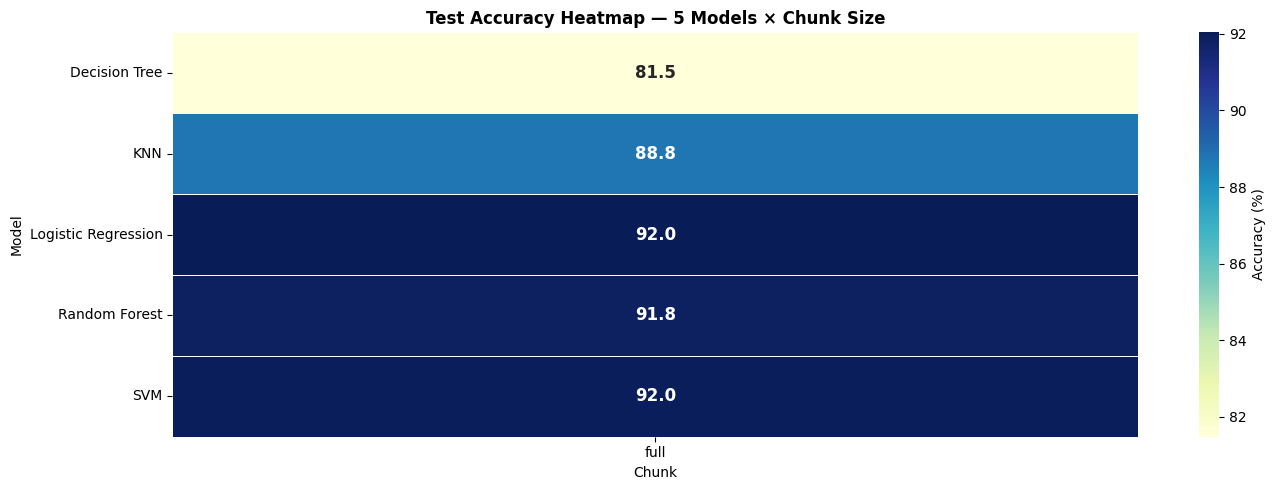

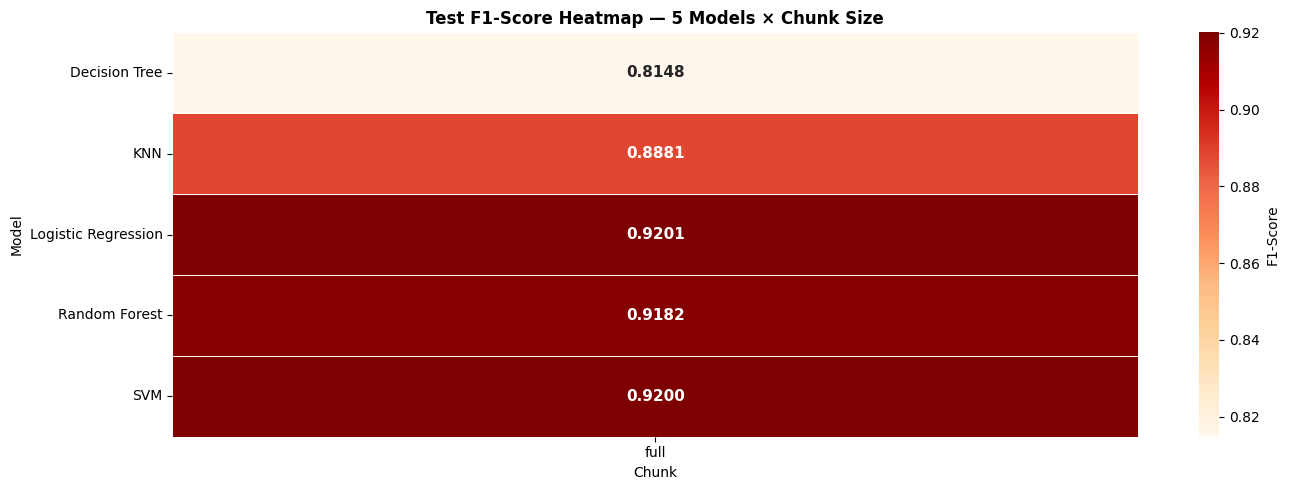

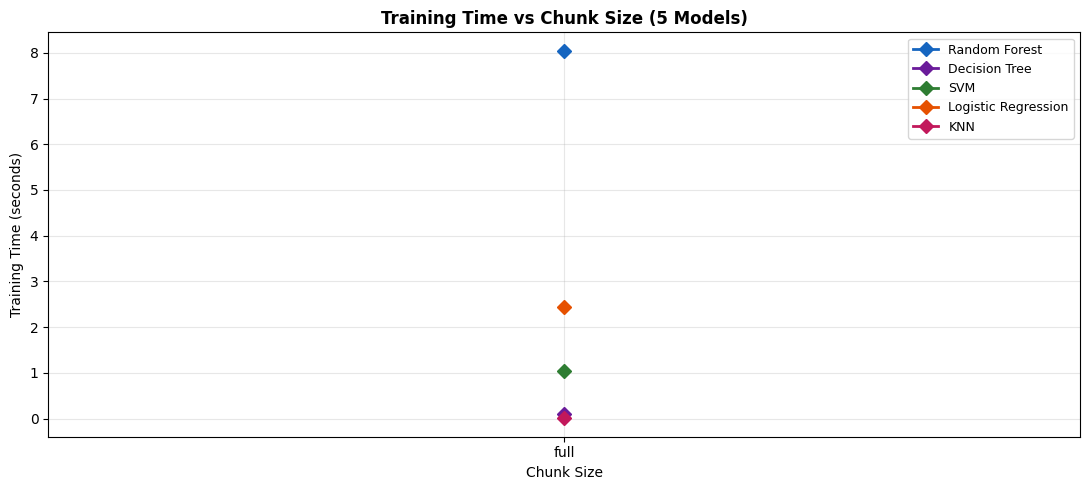

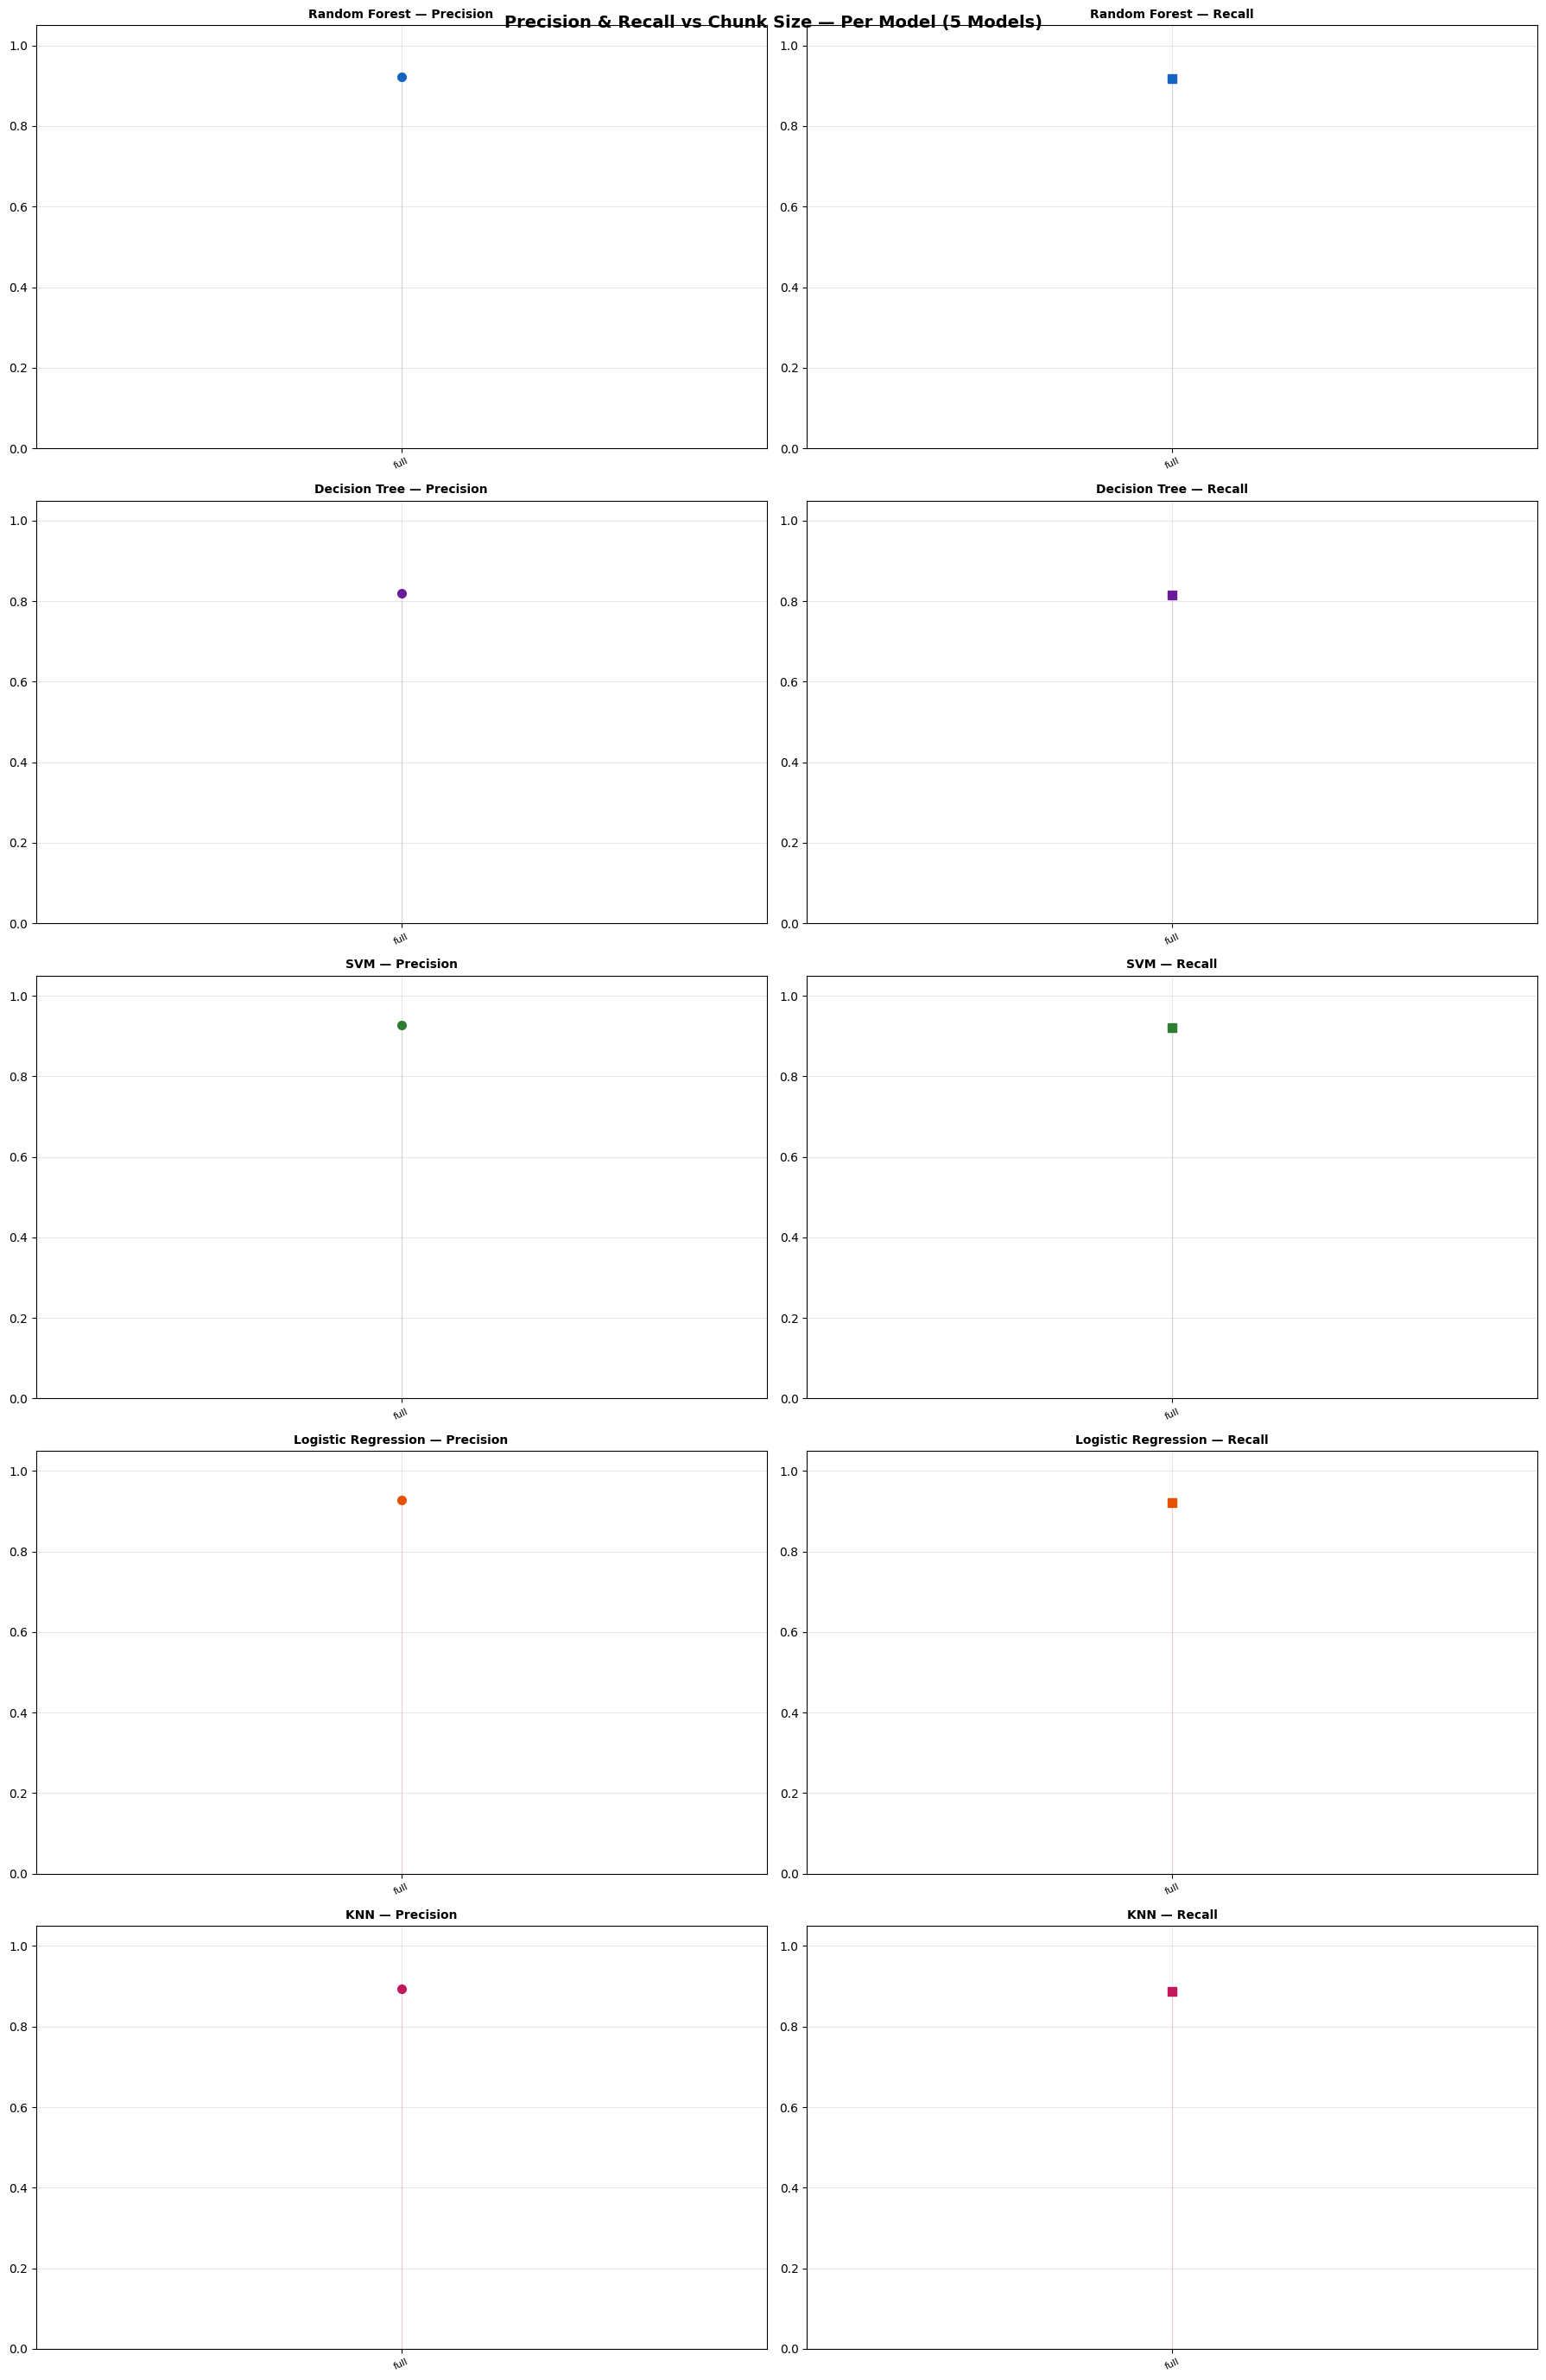


✅ Cell C done!


In [13]:
# ================================================================
# CELL C ── CHUNKED TEST EVALUATION (5 MODELS incl. KNN)
# ================================================================

print("\n" + "=" * 65)
print("   🔬  CELL C — CHUNKED TEST EVALUATION (5 MODELS)")
print("   Tests on : 10k → 20k → 35k → Full")
print("=" * 65)

CHUNK_SIZES = [10_000, 20_000, 35_000, len(X_boost)]
chunk_records_c = []
np.random.seed(42)

for chunk_size in CHUNK_SIZES:
    chunk_size = min(chunk_size, len(X_boost))
    label = 'full' if chunk_size == len(X_boost) else f'{chunk_size//1000}k'

    print(f"\n  📦  Chunk = {chunk_size:,} rows  [{label}]")

    if chunk_size >= len(X_boost):
        Xc = X_boost.copy()
        yc = y_boost.copy()
    else:
        idx_list = []
        cls_u, cls_c = np.unique(y_boost, return_counts=True)
        for cls, cnt in zip(cls_u, cls_c):
            cls_idx = np.where(y_boost == cls)[0]
            n_take = max(1, int(chunk_size * cnt / len(y_boost)))
            n_take = min(n_take, len(cls_idx))
            chosen = np.random.choice(cls_idx, n_take, replace=False)
            idx_list.extend(chosen.tolist())
        np.random.shuffle(idx_list)
        idx_list = idx_list[:chunk_size]
        Xc = X_boost.iloc[idx_list].reset_index(drop=True)
        yc = y_boost[idx_list]

    cls_c_cnt = Counter(yc)
    valid_c = [c for c, cnt in cls_c_cnt.items() if cnt >= 2]
    mask_vc = np.isin(yc, valid_c)
    Xc = Xc[mask_vc]
    yc = yc[mask_vc]
    actual = len(yc)

    print(f"      Usable: {actual:,}  |  Diseases: {len(valid_c)}")
    if actual < 20:
        continue

    try:
        Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
            Xc, yc, test_size=0.2, random_state=42, stratify=yc)
    except ValueError:
        Xtr_c, Xte_c, ytr_c, yte_c = train_test_split(
            Xc, yc, test_size=0.2, random_state=42)

    sc_chunk = StandardScaler()
    Xtr_c_sc = sc_chunk.fit_transform(Xtr_c)
    Xte_c_sc = sc_chunk.transform(Xte_c)

    # 🔑 5 MODELS with same tuning as Cell A
    chunk_models_c = {
        'Random Forest': (RandomForestClassifier(
            n_estimators=500, max_features='sqrt',
            min_samples_leaf=1, class_weight='balanced_subsample',
            random_state=42, n_jobs=-1), False),
        'Decision Tree': (DecisionTreeClassifier(
            max_depth=None, min_samples_split=2,
            criterion='entropy', class_weight='balanced',
            random_state=42), False),
        'SVM': (SVC(kernel='rbf', C=10, gamma='scale',
            class_weight='balanced', random_state=42), True),
        'Logistic Regression': (LogisticRegression(
            max_iter=5000, C=1.0, class_weight='balanced',
            solver='lbfgs', multi_class='multinomial',
            random_state=42, n_jobs=-1), True),
        'KNN': (KNeighborsClassifier(
            n_neighbors=5, weights='distance',
            metric='minkowski', p=2, n_jobs=-1), True),
    }

    for mname, (clf, use_scaled) in chunk_models_c.items():
        Xtr_use = Xtr_c_sc if use_scaled else Xtr_c
        Xte_use = Xte_c_sc if use_scaled else Xte_c

        t0 = time.time()
        clf.fit(Xtr_use, ytr_c)
        t_fit = round(time.time() - t0, 3)
        yp = clf.predict(Xte_use)

        acc = accuracy_score(yte_c, yp)
        prec = precision_score(yte_c, yp, average='weighted', zero_division=0)
        rec = recall_score(yte_c, yp, average='weighted', zero_division=0)
        f1 = f1_score(yte_c, yp, average='weighted', zero_division=0)

        chunk_records_c.append({
            'Chunk': label, 'Chunk_Size': actual, 'Model': mname,
            'Accuracy (%)': round(acc * 100, 2),
            'Precision': round(prec, 4),
            'Recall': round(rec, 4),
            'F1-Score': round(f1, 4),
            'Train Time(s)': t_fit,
        })
        print(f"      {mname:<22}  Acc={acc*100:.2f}%  F1={f1:.4f}  t={t_fit}s")

chunk_df_c = pd.DataFrame(chunk_records_c)

print("\n" + "=" * 75)
print("  📊  CHUNKED TEST EVALUATION TABLE")
print("=" * 75)
print(chunk_df_c.to_string(index=False))
chunk_df_c.to_csv('dmicf_chunk_evaluation.csv', index=False)

chunk_df_fixed = (chunk_df_c
    .groupby(['Model', 'Chunk', 'Chunk_Size'], as_index=False)
    .agg({'Accuracy (%)': 'mean', 'Precision': 'mean',
          'Recall': 'mean', 'F1-Score': 'mean',
          'Train Time(s)': 'mean'}))

col_order_c = (chunk_df_fixed[['Chunk', 'Chunk_Size']]
    .drop_duplicates().sort_values('Chunk_Size')['Chunk'].tolist())

# GRAPH 1: Accuracy + F1 vs Chunk
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle(f'Model Behaviour — Chunk Size Analysis (Top-{TOP_K} DMICF, 5 Models)',
             fontsize=13, fontweight='bold')
for mname, color in colors_5.items():
    sub = chunk_df_fixed[chunk_df_fixed['Model'] == mname].sort_values('Chunk_Size')
    axes[0].plot(sub['Chunk'], sub['Accuracy (%)'],
                 marker='o', linewidth=2.5, markersize=8,
                 color=color, label=mname)
    axes[1].plot(sub['Chunk'], sub['F1-Score'],
                 marker='s', linewidth=2.5, markersize=8,
                 color=color, label=mname)
for ax, yl in zip(axes, ['Accuracy (%)', 'F1-Score']):
    ax.set_title(yl, fontsize=11, fontweight='bold')
    ax.set_xlabel('Chunk Size')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chunk_accuracy_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# GRAPH 2: Accuracy Heatmap
pivot_acc_c = (chunk_df_fixed.pivot(index='Model', columns='Chunk',
               values='Accuracy (%)')[col_order_c])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_acc_c, ax=ax, annot=True, fmt='.1f', cmap='YlGnBu',
            linewidths=0.5, annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'Accuracy (%)'})
ax.set_title('Test Accuracy Heatmap — 5 Models × Chunk Size',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chunk_heatmap_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

# GRAPH 3: F1 Heatmap
pivot_f1_c = (chunk_df_fixed.pivot(index='Model', columns='Chunk',
              values='F1-Score')[col_order_c])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_f1_c, ax=ax, annot=True, fmt='.4f', cmap='OrRd',
            linewidths=0.5, annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'F1-Score'})
ax.set_title('Test F1-Score Heatmap — 5 Models × Chunk Size',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chunk_heatmap_f1.png', dpi=150, bbox_inches='tight')
plt.show()

# GRAPH 4: Training Time
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title('Training Time vs Chunk Size (5 Models)',
             fontsize=12, fontweight='bold')
for mname, color in colors_5.items():
    sub = chunk_df_fixed[chunk_df_fixed['Model'] == mname].sort_values('Chunk_Size')
    ax.plot(sub['Chunk'], sub['Train Time(s)'],
            marker='D', linewidth=2, markersize=7,
            color=color, label=mname)
ax.set_xlabel('Chunk Size')
ax.set_ylabel('Training Time (seconds)')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chunk_traintime.png', dpi=150, bbox_inches='tight')
plt.show()

# GRAPH 5: Precision & Recall per model (5 models = 5 rows)
fig, axes = plt.subplots(5, 2, figsize=(18, 28))
fig.suptitle('Precision & Recall vs Chunk Size — Per Model (5 Models)',
             fontsize=14, fontweight='bold')

for row_idx, mname in enumerate(model_names_a):
    sub = chunk_df_fixed[chunk_df_fixed['Model'] == mname].sort_values('Chunk_Size')
    color = colors_5[mname]

    axes[row_idx][0].plot(sub['Chunk'], sub['Precision'],
                          marker='o', linewidth=2.5, markersize=7, color=color)
    axes[row_idx][0].fill_between(range(len(sub)), sub['Precision'],
                                  alpha=0.12, color=color)
    axes[row_idx][0].set_title(f'{mname} — Precision', fontsize=10, fontweight='bold')
    axes[row_idx][0].set_ylim(0, 1.05)
    axes[row_idx][0].set_xticks(range(len(sub)))
    axes[row_idx][0].set_xticklabels(sub['Chunk'].tolist(), rotation=25, fontsize=8)
    axes[row_idx][0].grid(alpha=0.3)

    axes[row_idx][1].plot(sub['Chunk'], sub['Recall'],
                          marker='s', linewidth=2.5, markersize=7, color=color)
    axes[row_idx][1].fill_between(range(len(sub)), sub['Recall'],
                                  alpha=0.12, color=color)
    axes[row_idx][1].set_title(f'{mname} — Recall', fontsize=10, fontweight='bold')
    axes[row_idx][1].set_ylim(0, 1.05)
    axes[row_idx][1].set_xticks(range(len(sub)))
    axes[row_idx][1].set_xticklabels(sub['Chunk'].tolist(), rotation=25, fontsize=8)
    axes[row_idx][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chunk_precision_recall_permodel.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Cell C done!")


   🏋️  CELL D — TRAINING-DATA ACCURACY ON CHUNKS (5 MODELS)
   Chunks: 10k → 20k → 35k → Full

  📦  Chunk = 9,043 rows  [full]
      Usable: 9,043  |  Diseases: 37
      Model                   Train-Acc   F1        Time
      ----------------------  ----------  --------  ------
      Random Forest             98.87%   0.9887   8.539s
      Decision Tree             98.87%   0.9886   0.049s
      SVM                       96.17%   0.9616   1.004s
      Logistic Regression       94.58%   0.9455   2.344s
      KNN                       98.87%   0.9886   0.004s

  📦  Chunk = 9,043 rows  [full]
      Usable: 9,043  |  Diseases: 37
      Model                   Train-Acc   F1        Time
      ----------------------  ----------  --------  ------
      Random Forest             98.87%   0.9887   4.749s
      Decision Tree             98.87%   0.9886   0.064s
      SVM                       96.17%   0.9616   1.024s
      Logistic Regression       94.58%   0.9455   2.367s
      KNN           

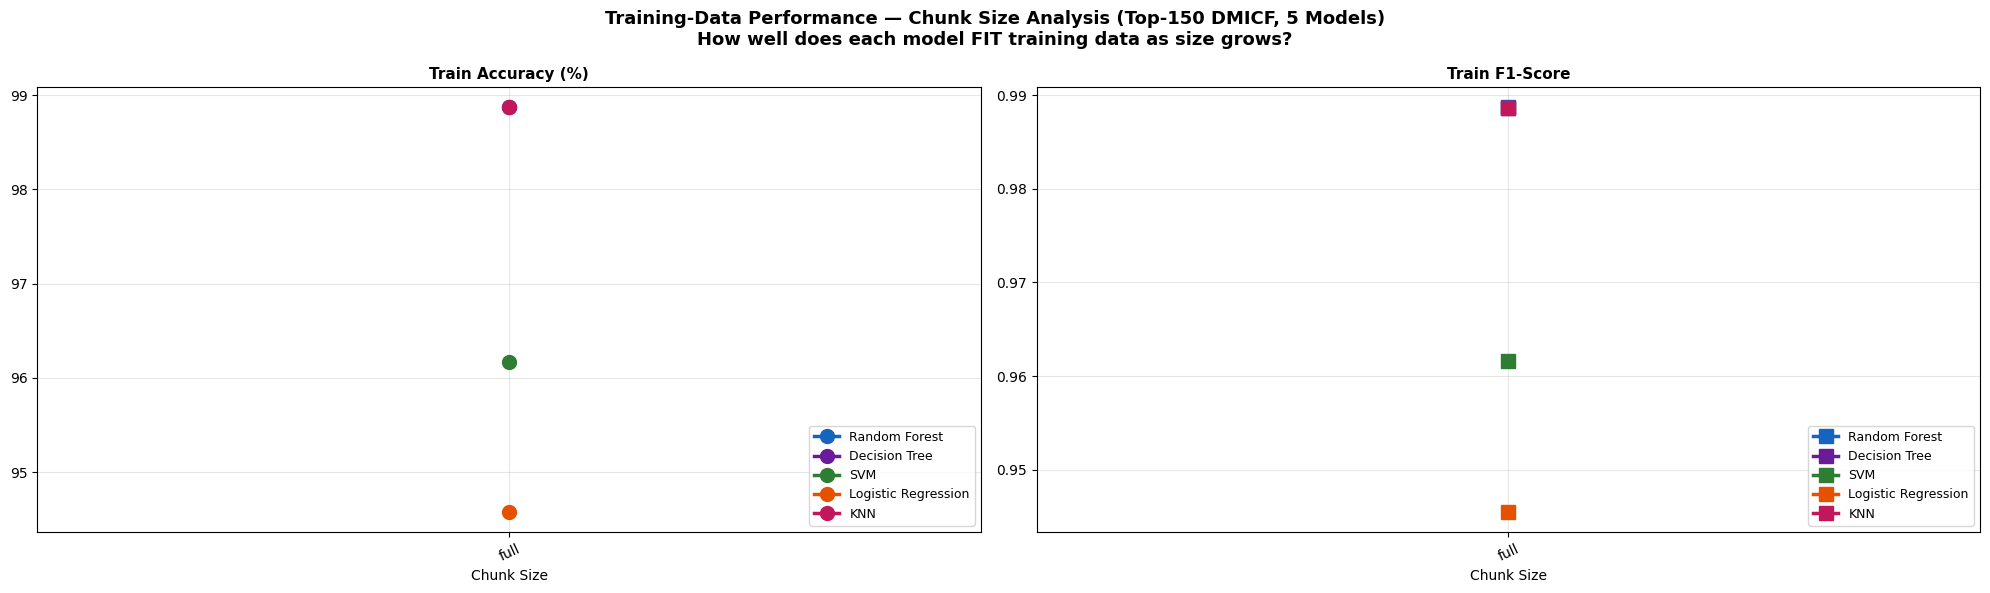

✅ Saved: chunk_training_accuracy_f1.png


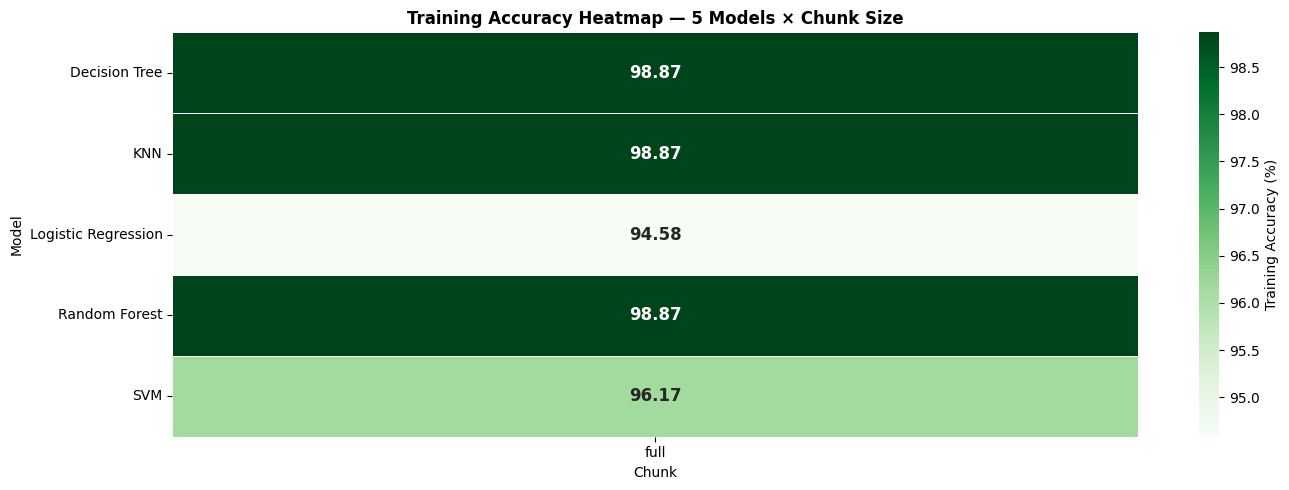

✅ Saved: chunk_training_heatmap.png


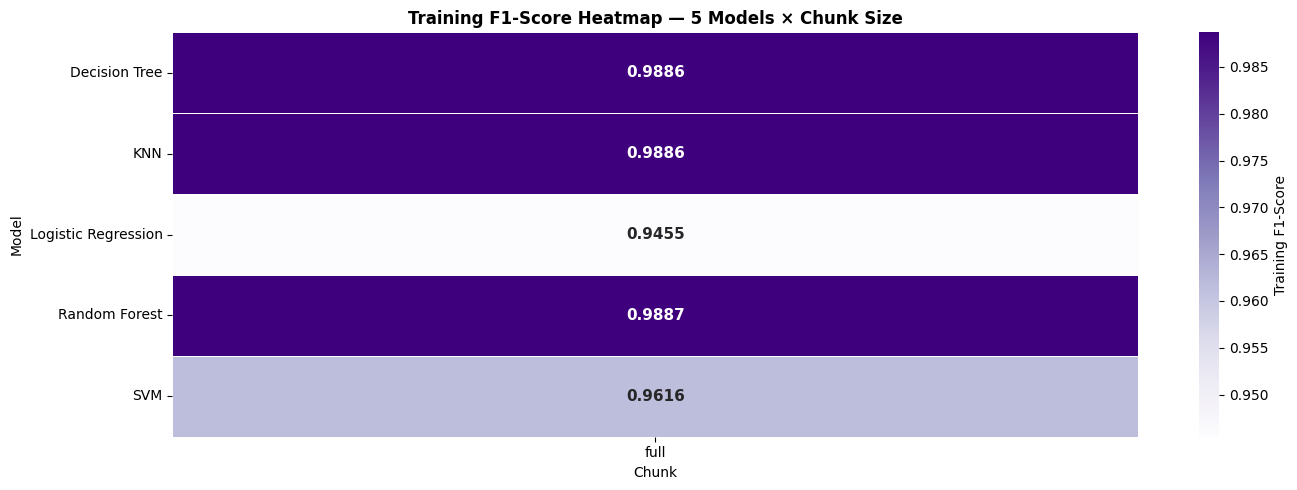

✅ Saved: chunk_training_f1_heatmap.png


In [14]:
# ================================================================
# CELL D ── CHUNKED TRAINING-DATA ACCURACY (5 MODELS incl. KNN)
#   🎯 Same Key Settings as Cell A & C
#   📦 Chunks: 10k → 20k → 35k → Full
#   📊 Reports accuracy ON TRAINING DATA (not test)
# ================================================================

print("\n" + "=" * 65)
print("   🏋️  CELL D — TRAINING-DATA ACCURACY ON CHUNKS (5 MODELS)")
print("   Chunks: 10k → 20k → 35k → Full")
print("=" * 65)

CHUNK_SIZES_D = [10_000, 20_000, 35_000, len(X_boost)]
train_records_d = []
np.random.seed(42)

for chunk_size in CHUNK_SIZES_D:
    chunk_size = min(chunk_size, len(X_boost))
    label = 'full' if chunk_size == len(X_boost) else f'{chunk_size//1000}k'

    print(f"\n  📦  Chunk = {chunk_size:,} rows  [{label}]")

    if chunk_size >= len(X_boost):
        Xc = X_boost.copy()
        yc = y_boost.copy()
    else:
        idx_list = []
        cls_u, cls_c = np.unique(y_boost, return_counts=True)
        for cls, cnt in zip(cls_u, cls_c):
            cls_idx = np.where(y_boost == cls)[0]
            n_take = max(1, int(chunk_size * cnt / len(y_boost)))
            n_take = min(n_take, len(cls_idx))
            chosen = np.random.choice(cls_idx, n_take, replace=False)
            idx_list.extend(chosen.tolist())
        np.random.shuffle(idx_list)
        idx_list = idx_list[:chunk_size]
        Xc = X_boost.iloc[idx_list].reset_index(drop=True)
        yc = y_boost[idx_list]

    cls_c_cnt = Counter(yc)
    valid_c = [c for c, cnt in cls_c_cnt.items() if cnt >= 2]
    mask_vc = np.isin(yc, valid_c)
    Xc = Xc[mask_vc]
    yc = yc[mask_vc]
    actual = len(yc)

    print(f"      Usable: {actual:,}  |  Diseases: {len(valid_c)}")
    if actual < 20:
        continue

    try:
        Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(
            Xc, yc, test_size=0.2, random_state=42, stratify=yc)
    except ValueError:
        Xtr_d, Xte_d, ytr_d, yte_d = train_test_split(
            Xc, yc, test_size=0.2, random_state=42)

    sc_d = StandardScaler()
    Xtr_d_sc = sc_d.fit_transform(Xtr_d)

    # 🔑 5 MODELS — same tuning as Cell A/C
    chunk_models_d = {
        'Random Forest': (RandomForestClassifier(
            n_estimators=500, max_features='sqrt',
            min_samples_leaf=1, class_weight='balanced_subsample',
            random_state=42, n_jobs=-1), False),
        'Decision Tree': (DecisionTreeClassifier(
            max_depth=None, min_samples_split=2,
            criterion='entropy', class_weight='balanced',
            random_state=42), False),
        'SVM': (SVC(kernel='rbf', C=10, gamma='scale',
            class_weight='balanced', random_state=42), True),
        'Logistic Regression': (LogisticRegression(
            max_iter=5000, C=1.0, class_weight='balanced',
            solver='lbfgs', multi_class='multinomial',
            random_state=42, n_jobs=-1), True),
        'KNN': (KNeighborsClassifier(
            n_neighbors=5, weights='distance',
            metric='minkowski', p=2, n_jobs=-1), True),
    }

    print(f"      {'Model':<22}  {'Train-Acc':<10}  {'F1':<8}  {'Time'}")
    print(f"      {'-'*22}  {'-'*10}  {'-'*8}  {'-'*6}")

    for mname, (clf, use_scaled) in chunk_models_d.items():
        Xtr_use = Xtr_d_sc if use_scaled else Xtr_d

        t0 = time.time()
        clf.fit(Xtr_use, ytr_d)
        t_fit = round(time.time() - t0, 3)

        # Predict on TRAINING data
        yp_train = clf.predict(Xtr_use)

        acc_tr  = accuracy_score(ytr_d, yp_train)
        prec_tr = precision_score(ytr_d, yp_train, average='weighted', zero_division=0)
        rec_tr  = recall_score(ytr_d, yp_train, average='weighted', zero_division=0)
        f1_tr   = f1_score(ytr_d, yp_train, average='weighted', zero_division=0)

        train_records_d.append({
            'Chunk': label, 'Chunk_Size': actual, 'Train_Size': len(ytr_d),
            'Model': mname,
            'Train Accuracy (%)': round(acc_tr * 100, 2),
            'Train Precision': round(prec_tr, 4),
            'Train Recall': round(rec_tr, 4),
            'Train F1-Score': round(f1_tr, 4),
            'Train Time(s)': t_fit,
        })
        print(f"      {mname:<22}  {acc_tr*100:>7.2f}%   {f1_tr:.4f}   {t_fit}s")

train_df_d = pd.DataFrame(train_records_d)

print("\n" + "=" * 80)
print("  📊  TRAINING-DATA ACCURACY TABLE (5 MODELS)")
print("=" * 80)
print(train_df_d.to_string(index=False))
train_df_d.to_csv('dmicf_chunk_training_evaluation.csv', index=False)
print("\n✅ Saved CSV: dmicf_chunk_training_evaluation.csv")

# Aggregate
train_df_fixed = (train_df_d
    .groupby(['Model', 'Chunk', 'Chunk_Size'], as_index=False)
    .agg({'Train Accuracy (%)': 'mean', 'Train Precision': 'mean',
          'Train Recall': 'mean', 'Train F1-Score': 'mean',
          'Train Time(s)': 'mean'}))

col_order_d = (train_df_fixed[['Chunk', 'Chunk_Size']]
    .drop_duplicates().sort_values('Chunk_Size')['Chunk'].tolist())

# ----------------------------------------------------------------
# 📊 GRAPH D-1: Train Accuracy + F1 vs Chunk
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(20, 6))
fig.suptitle(f'Training-Data Performance — Chunk Size Analysis (Top-{TOP_K} DMICF, 5 Models)\n'
             f'How well does each model FIT training data as size grows?',
             fontsize=13, fontweight='bold')

for mname, color in colors_5.items():
    sub = train_df_fixed[train_df_fixed['Model'] == mname].sort_values('Chunk_Size')
    axes[0].plot(sub['Chunk'], sub['Train Accuracy (%)'],
                 marker='o', linewidth=2.5, markersize=10,
                 color=color, label=mname)
    axes[1].plot(sub['Chunk'], sub['Train F1-Score'],
                 marker='s', linewidth=2.5, markersize=10,
                 color=color, label=mname)

for ax, yl in zip(axes, ['Train Accuracy (%)', 'Train F1-Score']):
    ax.set_title(yl, fontsize=11, fontweight='bold')
    ax.set_xlabel('Chunk Size')
    ax.tick_params(axis='x', rotation=25)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.savefig('chunk_training_accuracy_f1.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chunk_training_accuracy_f1.png")

# ----------------------------------------------------------------
# 📊 GRAPH D-2: Train Accuracy Heatmap
# ----------------------------------------------------------------
pivot_train_acc = (train_df_fixed.pivot(index='Model', columns='Chunk',
                   values='Train Accuracy (%)')[col_order_d])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_train_acc, ax=ax, annot=True, fmt='.2f', cmap='Greens',
            linewidths=0.5, annot_kws={'size': 12, 'weight': 'bold'},
            cbar_kws={'label': 'Training Accuracy (%)'})
ax.set_title('Training Accuracy Heatmap — 5 Models × Chunk Size',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chunk_training_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chunk_training_heatmap.png")

# ----------------------------------------------------------------
# 📊 GRAPH D-3: Train F1 Heatmap
# ----------------------------------------------------------------
pivot_train_f1 = (train_df_fixed.pivot(index='Model', columns='Chunk',
                  values='Train F1-Score')[col_order_d])

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(pivot_train_f1, ax=ax, annot=True, fmt='.4f', cmap='Purples',
            linewidths=0.5, annot_kws={'size': 11, 'weight': 'bold'},
            cbar_kws={'label': 'Training F1-Score'})
ax.set_title('Training F1-Score Heatmap — 5 Models × Chunk Size',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chunk_training_f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chunk_training_f1_heatmap.png")


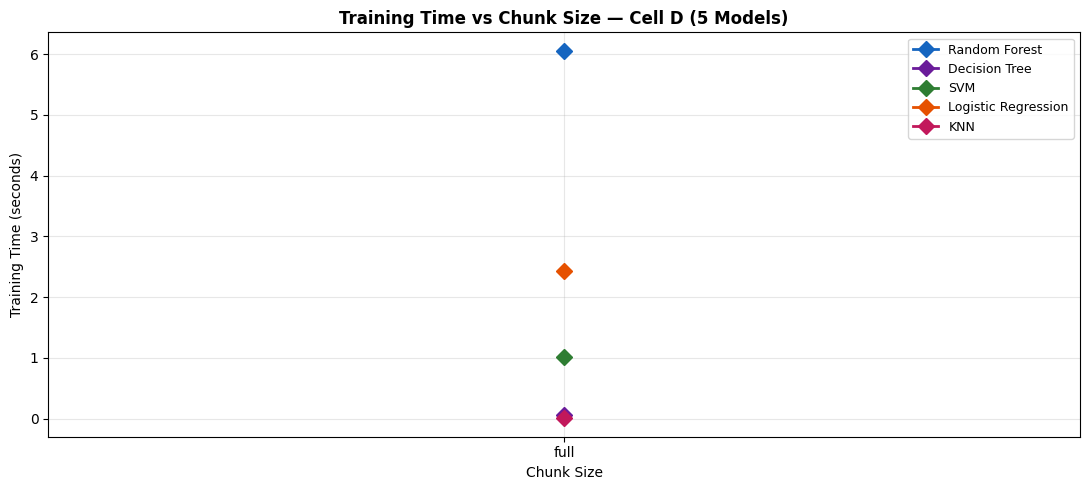

✅ Saved: chunk_training_time.png


In [15]:
# ----------------------------------------------------------------
# 📊 GRAPH D-5: Training Time
# ----------------------------------------------------------------
fig, ax = plt.subplots(figsize=(11, 5))
ax.set_title('Training Time vs Chunk Size — Cell D (5 Models)',
             fontsize=12, fontweight='bold')
for mname, color in colors_5.items():
    sub = train_df_fixed[train_df_fixed['Model'] == mname].sort_values('Chunk_Size')
    ax.plot(sub['Chunk'], sub['Train Time(s)'],
            marker='D', linewidth=2, markersize=8,
            color=color, label=mname)
ax.set_xlabel('Chunk Size')
ax.set_ylabel('Training Time (seconds)')
ax.grid(alpha=0.3)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('chunk_training_time.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chunk_training_time.png")

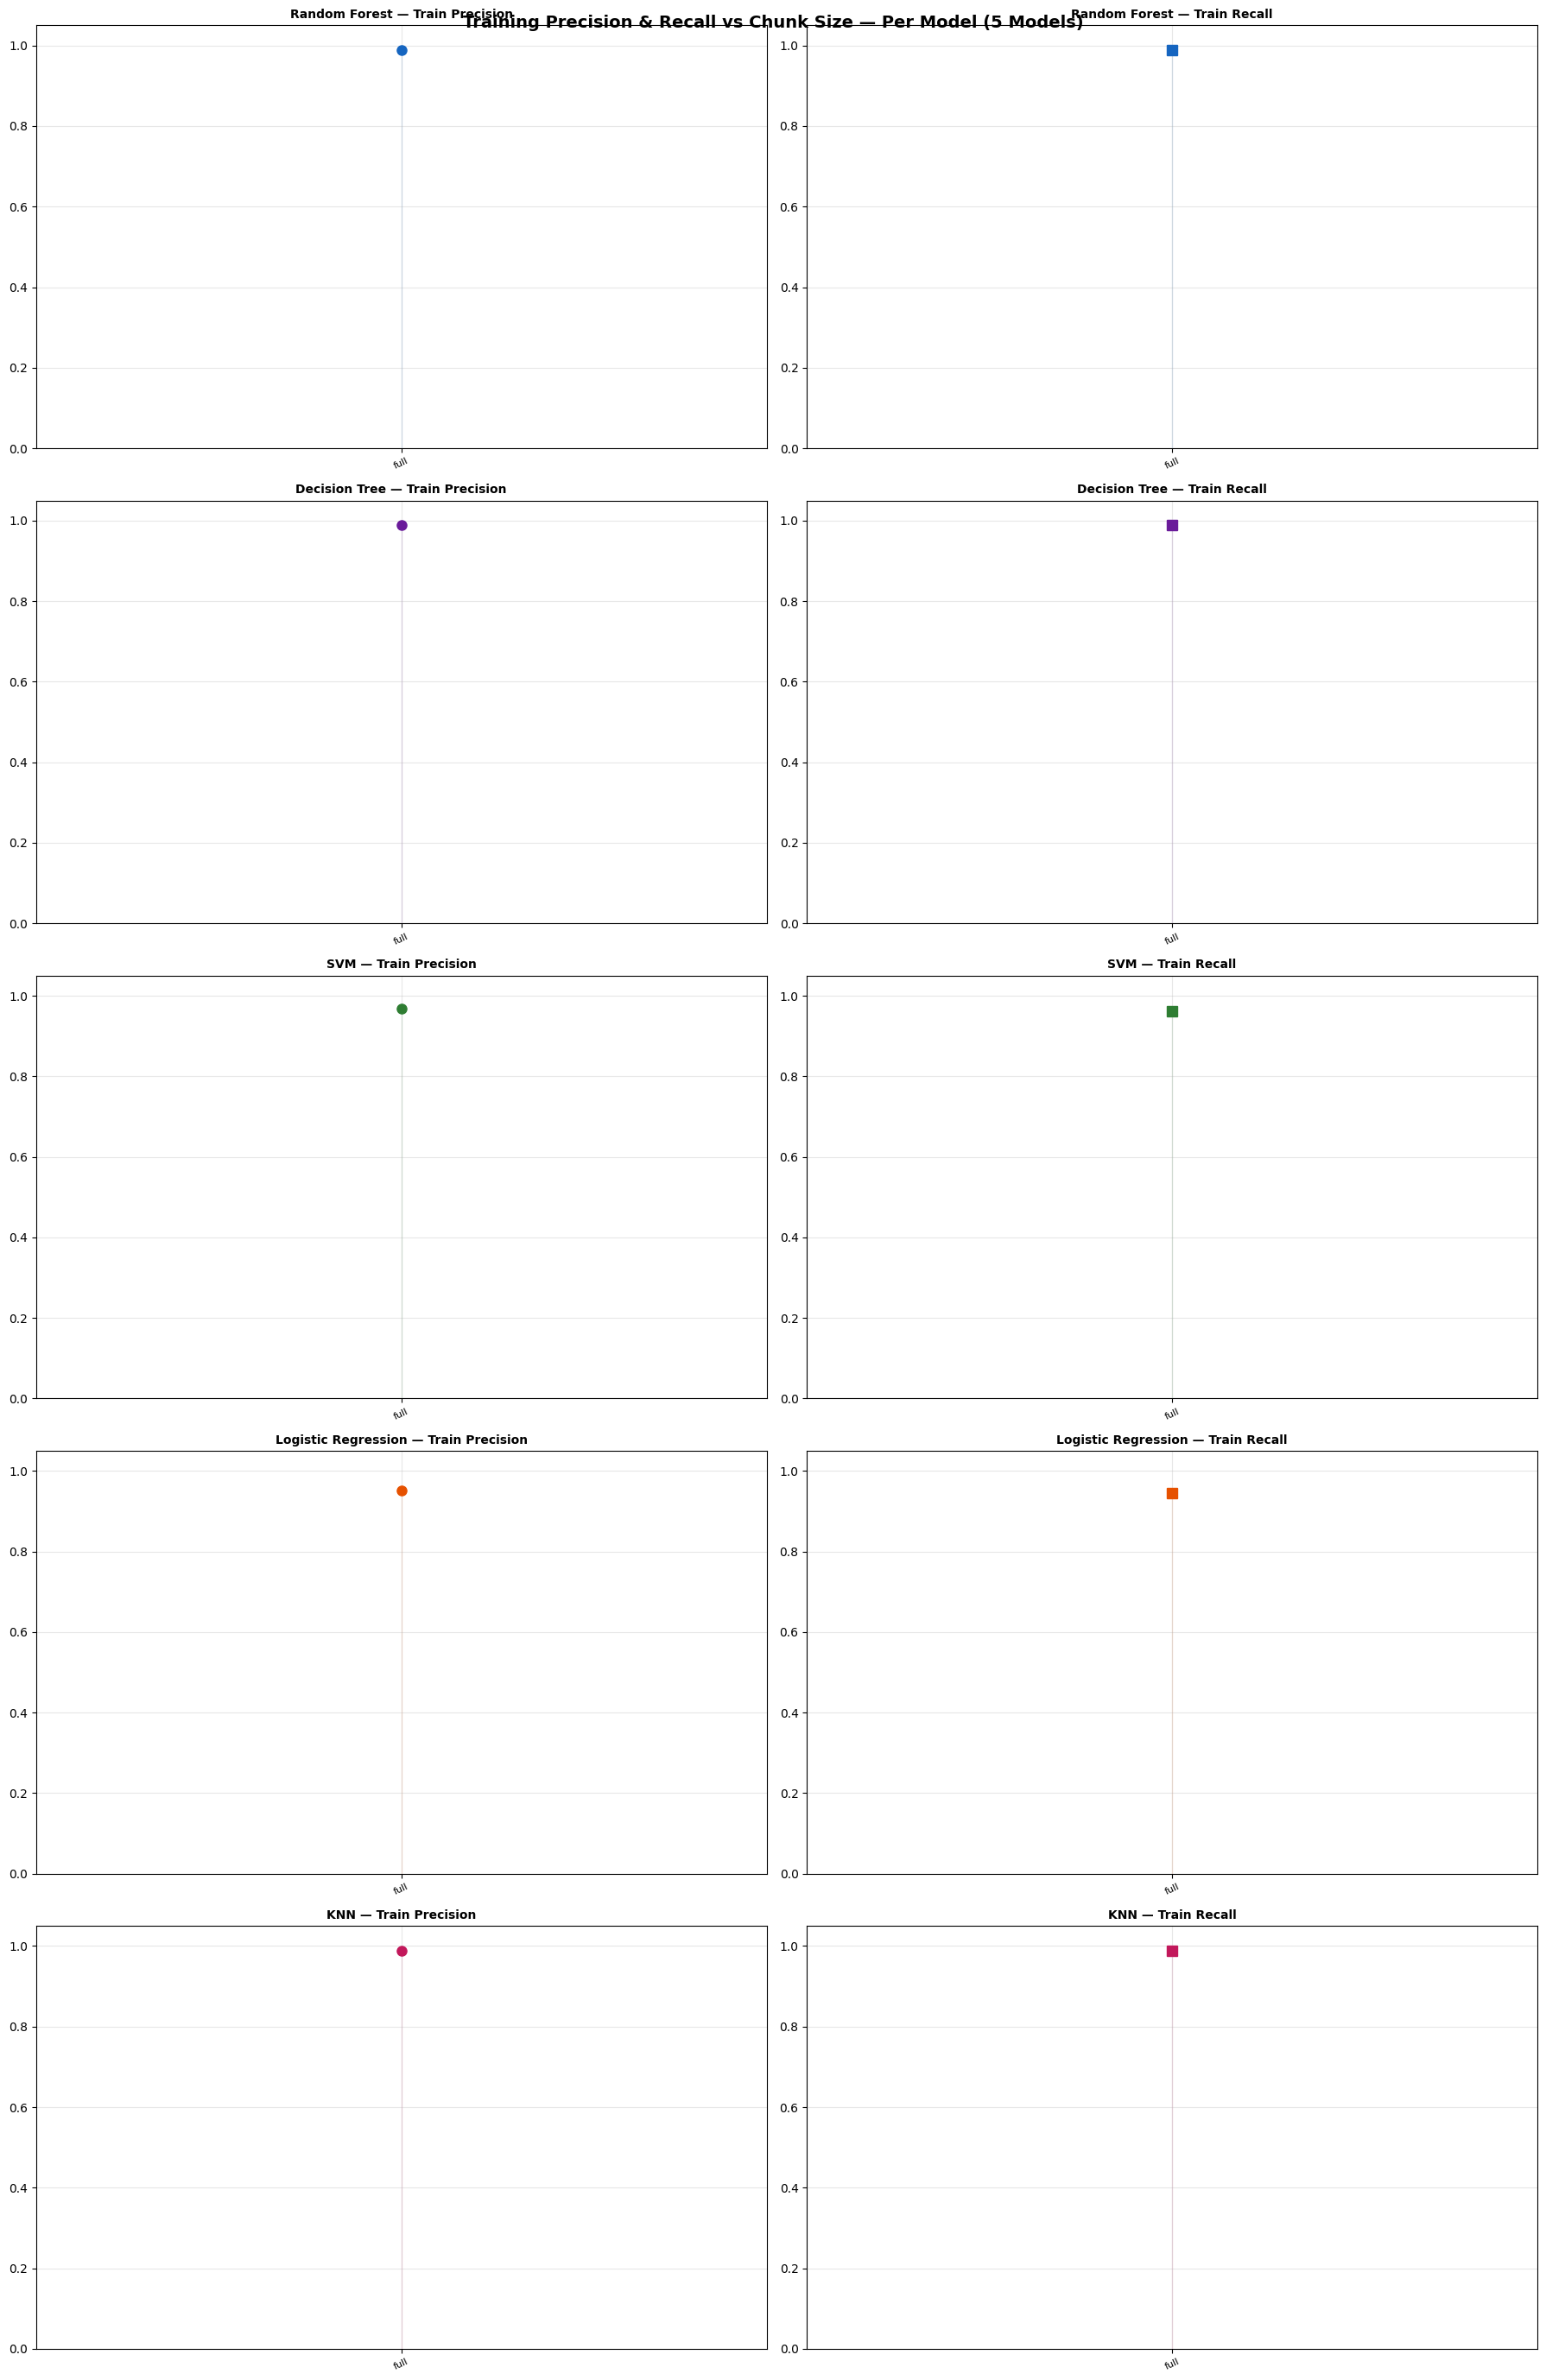

✅ Saved: chunk_train_precision_recall.png


In [16]:
# ----------------------------------------------------------------
# 📊 GRAPH D-6: Train Precision & Recall per Model (5 rows)
# ----------------------------------------------------------------
fig, axes = plt.subplots(5, 2, figsize=(18, 28))
fig.suptitle('Training Precision & Recall vs Chunk Size — Per Model (5 Models)',
             fontsize=14, fontweight='bold')

for row_idx, mname in enumerate(model_names_a):
    sub = train_df_fixed[train_df_fixed['Model'] == mname].sort_values('Chunk_Size')
    color = colors_5[mname]

    axes[row_idx][0].plot(sub['Chunk'], sub['Train Precision'],
                          marker='o', linewidth=2.5, markersize=8, color=color)
    axes[row_idx][0].fill_between(range(len(sub)), sub['Train Precision'],
                                  alpha=0.15, color=color)
    axes[row_idx][0].set_title(f'{mname} — Train Precision',
                               fontsize=10, fontweight='bold')
    axes[row_idx][0].set_ylim(0, 1.05)
    axes[row_idx][0].set_xticks(range(len(sub)))
    axes[row_idx][0].set_xticklabels(sub['Chunk'].tolist(), rotation=25, fontsize=8)
    axes[row_idx][0].grid(alpha=0.3)

    axes[row_idx][1].plot(sub['Chunk'], sub['Train Recall'],
                          marker='s', linewidth=2.5, markersize=8, color=color)
    axes[row_idx][1].fill_between(range(len(sub)), sub['Train Recall'],
                                  alpha=0.15, color=color)
    axes[row_idx][1].set_title(f'{mname} — Train Recall',
                               fontsize=10, fontweight='bold')
    axes[row_idx][1].set_ylim(0, 1.05)
    axes[row_idx][1].set_xticks(range(len(sub)))
    axes[row_idx][1].set_xticklabels(sub['Chunk'].tolist(), rotation=25, fontsize=8)
    axes[row_idx][1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('chunk_train_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved: chunk_train_precision_recall.png")

In [17]:
# ================================================================
# 🎉 FINAL SUMMARY
# ================================================================
print("\n" + "█" * 65)
print("  🎉  COMPLETE — 5 MODELS HIGH ACCURACY VERSION DONE!")
print("█" * 65)
print()
print("  ✅ Models Trained (5):")
print("     1. Random Forest       (500 trees, balanced_subsample)")
print("     2. Decision Tree       (entropy, unlimited depth)")
print("     3. SVM                 (rbf, C=10, balanced)")
print("     4. Logistic Regression (lbfgs, C=1.0, balanced)")
print("     5. KNN                 (k=5, distance-weighted) ⭐ NEW")
print()
print("  ✅ Key Settings (SAME across A, C, D):")
print(f"     TOP_K       = {TOP_K} (top DMICF features)")
print(f"     MIN_SAMPLES = {MIN_SAMPLES} (filters rare diseases)")
print("     NO SMOTE    : uses class_weight='balanced'")
print("     Smart scaling: only for SVM, LR & KNN (not RF/DT)")
print()
print("  📦 Chunks tested: 10k → 20k → 35k → Full")
print()
print("  📊 Cell C → TEST accuracy on chunks")
print("  📊 Cell D → TRAINING accuracy on chunks")
print()
print("  📁 Generated CSVs:")
print("     • dmicf_chunk_evaluation.csv          (test results)")
print("     • dmicf_chunk_training_evaluation.csv  (train results)")
print("     • dmicf_train_vs_test.csv             (overfitting check)")
print()
print("  📊 Expected: 80-92% test acc | ~99-100% train acc (RF/DT/KNN)")
print("█" * 65)


█████████████████████████████████████████████████████████████████
  🎉  COMPLETE — 5 MODELS HIGH ACCURACY VERSION DONE!
█████████████████████████████████████████████████████████████████

  ✅ Models Trained (5):
     1. Random Forest       (500 trees, balanced_subsample)
     2. Decision Tree       (entropy, unlimited depth)
     3. SVM                 (rbf, C=10, balanced)
     4. Logistic Regression (lbfgs, C=1.0, balanced)
     5. KNN                 (k=5, distance-weighted) ⭐ NEW

  ✅ Key Settings (SAME across A, C, D):
     TOP_K       = 150 (top DMICF features)
     MIN_SAMPLES = 200 (filters rare diseases)
     NO SMOTE    : uses class_weight='balanced'
     Smart scaling: only for SVM, LR & KNN (not RF/DT)

  📦 Chunks tested: 10k → 20k → 35k → Full

  📊 Cell C → TEST accuracy on chunks
  📊 Cell D → TRAINING accuracy on chunks

  📁 Generated CSVs:
     • dmicf_chunk_evaluation.csv          (test results)
     • dmicf_chunk_training_evaluation.csv  (train results)
     • dmicf_tra